# Clustering Filipino Households Based on Income and Spending Patterns Using K-Means (FIES Dataset)
---
## 1. Problem Definition
This study aims to identify clusters of Filipino households based on income and expenditure patterns using the FIES dataset. K-Means clustering will be applied to discover hidden socio-economic segments, helping reveal types of household spending behaviors in the Philippines.


### Objectives
- Group households into clusters based on spending patterns
- Find natural segments in income and expenditure
- Identify household spending behavior types
- Discover clusters of families with similar priority expenses

---
## 2. Data Collection
Description and Discussion

# 1. Background of the Study

## Title of the Study
### **Clustering Filipino Households Based on Income and Spending Patterns Using K-Means (FIES Dataset)**

***

## Source of Data
| Attribute | Details |
| :--- | :--- |
| **Dataset Name** | Family Income and Expenditure Survey (FIES) — Philippines |
| **Primary Source** | Philippine Statistics Authority (PSA) |
| **Acquisition Source** | Kaggle — Family Income and Expenditure Dataset |

***

## Brief Description of the Dataset
The dataset provides detailed information on Filipino households’ **annual income**, **sources of earnings**, and comprehensive **patterns of expenditure**. It contains both quantitative (numerical) and categorical features that describe the household’s socio-economic profile.

* **Number of Rows and Columns:** 41544 rows and 60 columns
* **Sample Variables:**
    * `Region` – geographic region of the household (Categorical)
    * `Household_Head_Age` – age of the family head (Quantitative)
    * `Education` – highest educational attainment (Categorical/Ordinal)
    * `Family_Size` – total number of family members (Quantitative)
    * `Total_Income` – total annual family income (Quantitative)
    * `Food_Expenditure`, `Education_Expenditure`, `Housing_Expenditure`, etc. – detailed spending categories (Quantitative)

***

## Machine Learning Task Details

### Selected Features (Independent Variables)
**to be done...**

### Target / Label Column (Dependent Variable)
**to be done...**



### Objective of the Study
This study aims to identify clusters of Filipino households based on income and expenditure patterns using the FIES dataset. K-Means clustering will be applied to discover hidden socio-economic segments, helping reveal types of household spending behaviors in the Philippines.

---
# 2. Data Collection / Loading
The dataset used in this study is the Family Income and Expenditure Survey (FIES), publicly available on Kaggle. It contains socio-economic and spending data of Filipino households, based on surveys originally conducted by the Philippine Statistics Authority (PSA). The data is stored in a CSV file format (Family Income and Expenditure.csv) and is imported using the pandas library for data analysis and manipulation.

In [1]:
# Importing necessary libraries
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Family Income and Expenditure.csv")


In [2]:
# rows and columns of the dataframe
df.shape

(41544, 60)

In [3]:
# displaying the first few rows of the dataframe 
pd.set_option('display.max_columns', None)
df.head()

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,Vegetables Expenditure,Restaurant and hotels Expenditure,Alcoholic Beverages Expenditure,Tobacco Expenditure,"Clothing, Footwear and Other Wear Expenditure",Housing and water Expenditure,Imputed House Rental Value,Medical Care Expenditure,Transportation Expenditure,Communication Expenditure,Education Expenditure,Miscellaneous Goods and Services Expenditure,Special Occasions Expenditure,Crop Farming and Gardening expenses,Total Income from Entrepreneurial Acitivites,Household Head Sex,Household Head Age,Household Head Marital Status,Household Head Highest Grade Completed,Household Head Job or Business Indicator,Household Head Occupation,Household Head Class of Worker,Type of Household,Total Number of Family members,Members with age less than 5 year old,Members with age 5 - 17 years old,Total number of family members employed,Type of Building/House,Type of Roof,Type of Walls,House Floor Area,House Age,Number of bedrooms,Tenure Status,Toilet Facilities,Electricity,Main Source of Water Supply,Number of Television,Number of CD/VCD/DVD,Number of Component/Stereo set,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,13460,3000,0,0,4607,63636,30000,3457,4776,2880,36200,34056,7200,19370,44370,Female,49,Single,Teacher Training and Education Sciences Programs,With Job/Business,General elementary education teaching professi...,Worked for government/government corporation,Extended Family,4,0,1,1,Single house,"Strong material(galvanized,iron,al,tile,concre...",Strong,80,75,3,Own or owner-like possession of house and lot,"Water-sealed, sewer septic tank, used exclusiv...",1,"Own use, faucet, community water system",1,1,0,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,7833,2360,960,2132,8230,41370,27000,3520,12900,5700,29300,9150,1500,0,0,Male,40,Married,Transport Services Programs,With Job/Business,Transport conductors,Worked for private establishment,Single Family,3,0,1,2,Single house,"Strong material(galvanized,iron,al,tile,concre...",Strong,42,15,2,Own or owner-like possession of house and lot,"Water-sealed, sewer septic tank, used exclusiv...",1,"Own use, faucet, community water system",1,1,1,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,3795,4545,270,4525,2735,14340,7200,70,324,420,425,6450,500,0,0,Male,39,Married,Grade 3,With Job/Business,Farmhands and laborers,Worked for private establishment,Single Family,6,0,4,3,Single house,"Light material (cogon,nipa,anahaw)",Light,35,12,1,Own or owner-like possession of house and lot,"Water-sealed, sewer septic tank, shared with o...",0,"Shared, faucet, community water system",0,0,0,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,7887,6280,480,0,1390,16638,6600,60,6840,660,300,3762,500,15580,15580,Male,52,Married,Elementary Graduate,With Job/Business,Rice farmers,Employer in own family-operated farm or business,Single Family,3,0,3,2,Single house,"Light material (cogon,nipa,anahaw)",Light,30,15,1,Own or owner-like possession of house and lot,Closed pit,1,"Own use, faucet, community water system",1,0,0,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,11260,6400,1040,0,4620,31122,16800,140,6996,2100,0,8472,1000,18887,75687,Male,65,Married,Elementary Graduate,With Job/Business,General managers/managing proprietors in trans...,Self-employed wihout any employee,Single Family,4,0,0,2,Single house,"Light material (cogon,nipa,an

---
# 3. Data Information and Summary Statistics
This section provides an overview of the dataset's structure, data types, and the initial statistical distribution of the variables, which is crucial for identifying necessary preprocessing and cleaning steps

In [4]:
# dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 60 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Total Household Income                         41544 non-null  int64 
 1   Region                                         41544 non-null  object
 2   Total Food Expenditure                         41544 non-null  int64 
 3   Main Source of Income                          41544 non-null  object
 4   Agricultural Household indicator               41544 non-null  int64 
 5   Bread and Cereals Expenditure                  41544 non-null  int64 
 6   Total Rice Expenditure                         41544 non-null  int64 
 7   Meat Expenditure                               41544 non-null  int64 
 8   Total Fish and  marine products Expenditure    41544 non-null  int64 
 9   Fruit Expenditure                              41544 non-null

In [5]:
df.shape

(41544, 60)

In [6]:
# check dataframe shape if have null values
df.isnull().sum()

Total Household Income                              0
Region                                              0
Total Food Expenditure                              0
Main Source of Income                               0
Agricultural Household indicator                    0
Bread and Cereals Expenditure                       0
Total Rice Expenditure                              0
Meat Expenditure                                    0
Total Fish and  marine products Expenditure         0
Fruit Expenditure                                   0
Vegetables Expenditure                              0
Restaurant and hotels Expenditure                   0
Alcoholic Beverages Expenditure                     0
Tobacco Expenditure                                 0
Clothing, Footwear and Other Wear Expenditure       0
Housing and water Expenditure                       0
Imputed House Rental Value                          0
Medical Care Expenditure                            0
Transportation Expenditure  

In [7]:
df.describe()

,Total Household Income,Total Food Expenditure,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,Vegetables Expenditure,Restaurant and hotels Expenditure,Alcoholic Beverages Expenditure,Tobacco Expenditure,"Clothing, Footwear and Other Wear Expenditure",Housing and water Expenditure,Imputed House Rental Value,Medical Care Expenditure,Transportation Expenditure,Communication Expenditure,Education Expenditure,Miscellaneous Goods and Services Expenditure,Special Occasions Expenditure,Crop Farming and Gardening expenses,Total Income from Entrepreneurial Acitivites,Household Head Age,Total Number of Family members,Members with age less than 5 year old,Members with age 5 - 17 years old,Total number of family members employed,House Floor Area,House Age,Number of bedrooms,Electricity,Number of Television,Number of CD/VCD/DVD,Number of Component/Stereo set,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
count,4.154400e+04,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,4.154400e+04,4.154400e+04,4.154400e+04,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,4.154400e+04,4.154400e+04,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000
mean,2.475556e+05,85099.158194,0.429858,25133.723642,18195.825005,10540.072574,10529.318337,2550.474990,5006.918568,15436.566075,1085.068121,2294.736183,4954.621076,3.837547e+04,2.092154e+04,7.160231e+03,11806.344454,4095.492057,7473.500481,12522.071635,5265.726001,1.381686e+04,5.437624e+04,51.381451,4.635182,0.410216,1.362579,1.272699,55.603360,20.125505,1.788008,0.890815,0.856875,0.435225,0.162141,0.394184,0.319806,0.129814,0.081215,0.060610,1.905738,0.315015,0.135038,0.013119,0.289885
std,2.868805e+05,51637.947682,0.676666,13466.482984,11727.224350,10497.727757,7812.201613,2969.752879,3300.175236,23705.195929,2174.431913,3998.977131,7496.500945,5.311168e+04,3.937152e+04,2.690200e+04,19351.213715,7298.822614,21219.170907,17547.027921,13279.593681,4.764378e+04,1.471428e+05,14.166081,2.280252,0.694390,1.408000,1.149152,55.023165,14.295452,1.105664,0.311875,0.646306,0.560125,0.389108,0.537025,0.478482,0.448673,0.346786,0.276732,1.558130,0.739698,0.354083,0.127171,0.558408
min,1.128500e+04,2947.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.950000e+03,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,9.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.048950e+05,51017.250000,0.000000,16556.000000,11020.000000,3353.750000,5504.000000,1024.750000,2873.000000,1930.000000,0.000000,0.000000,1365.000000,1.308000e+04,6.000000e+03,3.000000e+02,2412.000000,564.000000,0.000000,3792.000000,0.000000,0.000000e+00,0.000000e+00,41.000000,3.000000,0.000000,0.000000,0.000000,25.000000,10.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.640795e+05,72985.500000,0.000000,23324.000000,16620.000000,7332.500000,8695.000000,1820.000000,4314.000000,7314.000000,270.000000,300.000000,2740.000000,2.299200e+04,1.080000e+04,1.125000e+03,6036.000000,1506.000000,880.000000,6804.000000,1

## Findings:
- The dataset contains 41,544 rows (representing individual families/households) and 60 columns (features). 
- A check for null values across the entire dataset revealed zero missing entries (as confirmed by the count row being uniform across all columns) except for Household Head Occupation that has 7,536 missing values.
- the data is complete but exhibits high skewness and large differences in feature scales. The next steps in data cleaning and pre-processing must focus on handling the income skew and scaling all numerical features.



---
# 4. Data Cleaning
This section addresses inconsistencies and prepares the raw features for the subsequent Data Engineering steps.

### 4.1 Dropping Unneeded Columns
This process involves permanently removing columns from the DataFrame that are redundant, irrelevant, or potentially harmful to the modeling process.

In [8]:
# list all the columns in the dataframe
pd.DataFrame({'Column Names': df.columns})

,Column Names
0,Total Household Income
1,Region
2,Total Food Expenditure
3,Main Source of Income
4,Agricultural Household indicator
5,Bread and Cereals Expenditure
6,Total Rice Expenditure
7,Meat Expenditure
8,Total Fish and marine products Expenditure
9,Fruit Expenditure


In [9]:
# drop unnecessary columns

df.drop(columns=[
    # Detailed Expenditures (Kept the aggregate 'Total Food Expenditure' instead)
    'Bread and Cereals Expenditure',
    'Total Rice Expenditure',
    'Meat Expenditure',
    'Total Fish and  marine products Expenditure',
    'Fruit Expenditure',
    'Vegetables Expenditure',

    # Features with High Missing Data or High Cardinality
    'Household Head Occupation',
    'Household Head Class of Worker',

    # Redundant, Low-Variance, or Noisy Features
    'Agricultural Household indicator',
    'Crop Farming and Gardening expenses',
    'Clothing, Footwear and Other Wear Expenditure',
    'House Age',
    'Type of Roof',
    'Type of Walls',
    'Toilet Facilities',
    'Electricity',
    'Main Source of Water Supply',

    # Obsolete or Low-Differential Assets
    'Number of Television', # Dropping this as it's low-variance
    'Number of CD/VCD/DVD',
    'Number of Component/Stereo set',
    'Number of Landline/wireless telephones',
    'Number of Motorized Banca'  # Very niche/low frequency asset
], inplace=True)

# list all the columns in the dataframe after dropping unneeded columns
pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values
})

,Column,Type
0,Total Household Income,int64
1,Region,object
2,Total Food Expenditure,int64
3,Main Source of Income,object
4,Restaurant and hotels Expenditure,int64
5,Alcoholic Beverages Expenditure,int64
6,Tobacco Expenditure,int64
7,Housing and water Expenditure,int64
8,Imputed House Rental Value,int64
9,Medical Care Expenditure,int64


## Summary:
- Dropped the original 22 noisy/redundant/detailed columns to ensure the model learns from the predictors and not the answer itself and prevents multicollinearity.
- inputs that have a lot of missing data are dropped.
- All rows have inputs and is not null.



---
# 5. Data Engineering / pre-processing
This section transform the cleaned, consistent data into a format that machine learning algorithms can efficiently process. It is primarily focused on making the features mathematically and statistically suitable for modeling.

## 5.1 Feature Encoding (Handling Categorical Data)
Machine learning models only understand numbers, so any text-based (categorical) data must be converted into numerical representations. The goal of this phase was to transform the cleaned dataset, which contained a mix of numerical and categorical variables, into a purely numerical matrix that K-Means clustering could process. Since K-Means is a distance-based algorithm, features must be represented numerically to ensure accurate distance calculations.

In [10]:
# check all object type columns
df.dtypes[df.dtypes == 'object']

Region                                      object
Main Source of Income                       object
Household Head Sex                          object
Household Head Marital Status               object
Household Head Highest Grade Completed      object
Household Head Job or Business Indicator    object
Type of Household                           object
Type of Building/House                      object
Tenure Status                               object
dtype: object

In [11]:
# check first 5 rows of object type columns
df.select_dtypes(include=['object']).head()

,Region,Main Source of Income,Household Head Sex,Household Head Marital Status,Household Head Highest Grade Completed,Household Head Job or Business Indicator,Type of Household,Type of Building/House,Tenure Status
0,CAR,Wage/Salaries,Female,Single,Teacher Training and Education Sciences Programs,With Job/Business,Extended Family,Single house,Own or owner-like possession of house and lot
1,CAR,Wage/Salaries,Male,Married,Transport Services Programs,With Job/Business,Single Family,Single house,Own or owner-like possession of house and lot
2,CAR,Wage/Salaries,Male,Married,Grade 3,With Job/Business,Single Family,Single house,Own or owner-like possession of house and lot
3,CAR,Wage/Salaries,Male,Married,Elementary Graduate,With Job/Business,Single Family,Single house,Own or owner-like possession of house and lot
4,CAR,Wage/Salaries,Male,Married,Elementary Graduate,With Job/Business,Single Family,Single house,Own or owner-like possession of house and lot


In [12]:
# For specific columns
columns_to_check = ['Region', 'Main Source of Income','Household Head Sex', 
                    'Household Head Marital Status', 'Household Head Highest Grade Completed',
                    'Type of Household', 'Type of Building/House', 'Tenure Status']

for col in columns_to_check:
    print(f"\n{col}:")
    print(df[col].unique())


Region:
['CAR' 'Caraga' 'VI - Western Visayas' 'V - Bicol Region' ' ARMM'
 'III - Central Luzon' 'II - Cagayan Valley' 'IVA - CALABARZON'
 'VII - Central Visayas' 'X - Northern Mindanao' 'XI - Davao Region'
 'VIII - Eastern Visayas' 'I - Ilocos Region' 'NCR' 'IVB - MIMAROPA'
 'XII - SOCCSKSARGEN' 'IX - Zasmboanga Peninsula']

Main Source of Income:
['Wage/Salaries' 'Other sources of Income' 'Enterpreneurial Activities']

Household Head Sex:
['Female' 'Male']

Household Head Marital Status:
['Single' 'Married' 'Widowed' 'Divorced/Separated' 'Annulled' 'Unknown']

Household Head Highest Grade Completed:
['Teacher Training and Education Sciences Programs'
 'Transport Services Programs' 'Grade 3' 'Elementary Graduate'
 'Second Year High School' 'Third Year High School'
 'Business and Administration Programs' 'First Year College'
 'High School Graduate'
 'Other Programs in Education at the Third Level, First Stage, of the Type that Leads to an Award not Equivalent to a First University or 

In [13]:
# print the count of unique values in each column
df_to_check_without_int_col = df.select_dtypes(exclude=['int64', 'float64'])

for col in columns_to_check:
    unique_counts = df_to_check_without_int_col.nunique()

print("\nUnique value counts for categorical columns:\n")
print(unique_counts)


Unique value counts for categorical columns:

Region                                      17
Main Source of Income                        3
Household Head Sex                           2
Household Head Marital Status                6
Household Head Highest Grade Completed      46
Household Head Job or Business Indicator     2
Type of Household                            3
Type of Building/House                       6
Tenure Status                                8
dtype: int64


## Findings:
- columns that has low cardinality (Region, Main Source of Income, etc.) can be encode using **one-hot encoding** and **binary-encoding** (Male = 0, Female = 1)
- columns with too many cardinality like **Household Head Highest Grade Completed** needs to be encoded in different way

---

## 5.1.1 One-hot Encoding and Binary Encoding Columns
To prepare the dataset for machine learning, categorical variables must be converted into numerical form so that the Random Forest Classifier can interpret them effectively. Two encoding techniques were used in this study — **One-Hot Encoding and Binary Encoding** — depending on the number of unique categories in each column.

- **One-hot encoding** - was applied to categorical features with a small number of unique values.
- **Binary encoding** - was used for features containing only two categories.

In [14]:
print(f"Original shape: {df.shape}")

# List of columns to one-hot encode
categorical_columns = [
    'Region',
    'Main Source of Income',
    'Household Head Marital Status',
    'Type of Building/House',
    'Tenure Status',
    'Type of Household',
    'Household Head Job or Business Indicator'
]

# One-hot encode the categorical columns
df = pd.get_dummies(df, columns=categorical_columns, drop_first=False)

from sklearn.preprocessing import LabelEncoder

# Encode Sex column (Female = 0, Male = 1)
le = LabelEncoder()
df['Household Head Sex'] = le.fit_transform(df['Household Head Sex'])


# Display the shape before and after encoding

print(f"Encoded shape: {df.shape}")

df.head(3)

Original shape: (41544, 38)
Encoded shape: (41544, 76)


,Total Household Income,Total Food Expenditure,Restaurant and hotels Expenditure,Alcoholic Beverages Expenditure,Tobacco Expenditure,Housing and water Expenditure,Imputed House Rental Value,Medical Care Expenditure,Transportation Expenditure,Communication Expenditure,Education Expenditure,Miscellaneous Goods and Services Expenditure,Special Occasions Expenditure,Total Income from Entrepreneurial Acitivites,Household Head Sex,Household Head Age,Household Head Highest Grade Completed,Total Number of Family members,Members with age less than 5 year old,Members with age 5 - 17 years old,Total number of family members employed,House Floor Area,Number of bedrooms,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorcycle/Tricycle,Region_ ARMM,Region_CAR,Region_Caraga,Region_I - Ilocos Region,Region_II - Cagayan Valley,Region_III - Central Luzon,Region_IVA - CALABARZON,Region_IVB - MIMAROPA,Region_IX - Zasmboanga Peninsula,Region_NCR,Region_V - Bicol Region,Region_VI - Western Visayas,Region_VII - Central Visayas,Region_VIII - Eastern Visayas,Region_X - Northern Mindanao,Region_XI - Davao Region,Region_XII - SOCCSKSARGEN,Main Source of Income_Enterpreneurial Activities,Main Source of Income_Other sources of Income,Main Source of Income_Wage/Salaries,Household Head Marital Status_Annulled,Household Head Marital Status_Divorced/Separated,Household Head Marital Status_Married,Household Head Marital Status_Single,Household Head Marital Status_Unknown,Household Head Marital Status_Widowed,Type of Building/House_Commercial/industrial/agricultural building,Type of Building/House_Duplex,Type of Building/House_Institutional living quarter,Type of Building/House_Multi-unit residential,"Type of Building/House_Other building unit (e.g. cave, boat)",Type of Building/House_Single house,Tenure Status_Not Applicable,"Tenure Status_Own house, rent lot","Tenure Status_Own house, rent-free lot with consent of owner","Tenure Status_Own house, rent-free lot without consent of owner",Tenure Status_Own or owner-like possession of house and lot,Tenure Status_Rent house/room including lot,Tenure Status_Rent-free house and lot with consent of owner,Tenure Status_Rent-free house and lot without consent of owner,Type of Household_Extended Family,Type of Household_Single Family,Type of Household_Two or More Nonrelated Persons/Members,Household Head Job or Business Indicator_No Job/Business,Household Head Job or Business Indicator_With Job/Business
0,480332,117848,3000,0,0,63636,30000,3457,4776,2880,36200,34056,7200,44370,0,49,Teacher Training and Education Sciences Programs,4,0,1,1,80,3,1,1,0,0,2,1,0,1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True
1,198235,67766,2360,960,2132,41370,27000,3520,12900,5700,29300,9150,1500,0,1,40,Transport Services Programs,3,0,1,2,42,2,0,1,0,0,3,1,0,2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True
2,82785,61609,4545,270,4525,14340,7200,70,324,420,425,6450,500,0,1,39,Grade 3,6,0,4,3,35,1,0,0,0,0,0,0,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True


---
## 5.1.3 Ordinal Encoding - Household Head Highest Grade Completed (46 Categories)
The “Household Head Highest Grade Completed” column contains 46 unique categories representing various levels of educational attainment. Since education follows a natural progression or order (from no education to postgraduate studies), it is most appropriate to represent this feature using Ordinal Encoding.

Ordinal Encoding converts each category into a numerical value based on its relative rank or educational level. This approach preserves the inherent order among categories, allowing the model to interpret higher numerical values as higher levels of education.

In [15]:
# All specific 'Programs' are assigned the same high rank (20) as they imply a degree/specialization.
education_rank_map = {
    # ------------------ Rank 1-9: Elementary School ------------------
    'No Grade Completed': 1,
    'Basic Programs': 2,
    'Preschool': 2,
    'Grade 1': 3,
    'Grade 2': 4,
    'Grade 3': 5,
    'Grade 4': 6,
    'Grade 5': 7,
    'Grade 6': 8,
    'Elementary Graduate': 9,

    # ------------------ Rank 10-13: High School ------------------
    'First Year High School': 10,
    'Second Year High School': 11,
    'Third Year High School': 12,
    'High School Graduate': 13,

    # ------------------ Rank 14-15: Post Secondary ------------------
    'First Year Post Secondary': 14,
    'Second Year Post Secondary': 15,

    # ------------------ Rank 16-19: College Years ------------------
    'First Year College': 16,
    'Second Year College': 17,
    'Third Year College': 18,
    'Fourth Year College': 19,

    # ------------------ Rank 20: Baccalaureate/Degree Programs ------------------
    # All 25 Program categories are ranked equally at 20 (Degree Equivalent)
    'Teacher Training and Education Sciences Programs': 20,
    'Transport Services Programs': 20,
    'Business and Administration Programs': 20,
    'Other Programs in Education at the Third Level, First Stage, of the Type that Leads to an Award not Equivalent to a First University or Baccalaureate Degree': 20,
    'Humanities Programs': 20,
    'Engineering and Engineering Trades Programs': 20,
    'Engineering and Engineering trades Programs': 20,
    'Social and Behavioral Science Programs': 20,
    'Agriculture, Forestry, and Fishery Programs': 20,
    'Health Programs': 20,
    'Security Services Programs': 20,
    'Computing/Information Technology Programs': 20,
    'Mathematics and Statistics Programs': 20,
    'Personal Services Programs': 20,
    'Law Programs': 20,
    'Journalism and Information Programs': 20,
    'Architecture and Building Programs': 20,
    'Manufacturing and Processing Programs': 20,
    'Life Sciences Programs': 20,
    'Other Programs of Education at the Third Level, First Stage, of the Type that Leads to a Baccalaureate or First University/Professional Degree (HIgher Education Level, First Stage, or Collegiate Education Level)': 20,
    'Social Services Programs': 20,
    'Physical Sciences Programs': 20,
    'Arts Programs': 20,
    'Veterinary Programs': 20,
    'Environmental Protection Programs': 20,

    # ------------------ Rank 21: Post Graduate ------------------
    'Post Baccalaureate': 21
}

column_name = 'Household Head Highest Grade Completed'

df['Education_Rank'] = df[column_name].map(education_rank_map)

df['Education_Rank'] = df['Education_Rank'].fillna(0).astype(int)

df = df.drop(columns=[column_name])

print("Ordinal Encoding applied successfully.\n")
print(df[['Education_Rank']].head())

Ordinal Encoding applied successfully.

   Education_Rank
0              20
1              20
2               5
3               9
4               9


In [16]:
df.dtypes

Total Household Income                                        int64
Total Food Expenditure                                        int64
Restaurant and hotels Expenditure                             int64
Alcoholic Beverages Expenditure                               int64
Tobacco Expenditure                                           int64
                                                              ...  
Type of Household_Single Family                                bool
Type of Household_Two or More Nonrelated Persons/Members       bool
Household Head Job or Business Indicator_No Job/Business       bool
Household Head Job or Business Indicator_With Job/Business     bool
Education_Rank                                                int64
Length: 76, dtype: object

In [17]:
# Identify all columns with boolean data type
boolean_columns = df.select_dtypes(include=['bool']).columns

if not boolean_columns.empty:
    df[boolean_columns] = df[boolean_columns].astype(int)
    print(f"Successfully converted {len(boolean_columns)} boolean columns to integer (0 or 1).")
    print("\nData Types of Converted Columns:")
    print(df[boolean_columns].dtypes)
else:
    print("No boolean columns found in the DataFrame. Ready for scaling.")

Successfully converted 45 boolean columns to integer (0 or 1).

Data Types of Converted Columns:
Region_ ARMM                                                          int64
Region_CAR                                                            int64
Region_Caraga                                                         int64
Region_I - Ilocos Region                                              int64
Region_II - Cagayan Valley                                            int64
Region_III - Central Luzon                                            int64
Region_IVA - CALABARZON                                               int64
Region_IVB - MIMAROPA                                                 int64
Region_IX - Zasmboanga Peninsula                                      int64
Region_NCR                                                            int64
Region_V - Bicol Region                                               int64
Region_VI - Western Visayas                                        

In [18]:
df.select_dtypes(include=['object']).head()

""
0
1
2
3
4


## Summary:
- Nominal categorical features—those without a natural order—were converted into numerical format using two methods: 
1. **One-Hot Encoding** applied to categorical columns with a moderate number of unique values and;
2. **Binary Encoding** applied to features with only two categories.

- The Household Head Highest Grade Completed column, which originally contained 46 unique descriptive entries, was handled using **Ordinal Encoding** due to its inherent, natural order.

- Following all encoding steps, the final feature set was converted to appropriate numerical data types (including casting all boolean columns to int) to prepare the matrix for the critical Feature Scaling stage.

---
## 5.2 Feature Scaling (Standardization)
**Ensuring Fair Distance** - K-Means is a distance-based algorithm that calculates the Euclidean distance between data points. If features have vastly different scales (e.g., Total Household Income in the hundreds of thousands vs. binary features like Household Head Sex at $0$ or $1$), the large-magnitude features would disproportionately dominate the distance calculations.

To prevent this bias, all features must be brought to a common scale by applying the StandardScaler.

In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

X = df.copy() 
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array, 
    columns=X.columns, 
    index=X.index
)

print("Feature Scaling (Standardization) complete.")
print("-" * 35)
print("Preview of Scaled Data:")
print(X_scaled.head())
print(f"\nFinal Feature Matrix shape: {X_scaled.shape}")

Feature Scaling (Standardization) complete.
-----------------------------------
Preview of Scaled Data:
   Total Household Income  Total Food Expenditure  \
0                0.811415                0.634209   
1               -0.171922               -0.335671   
2               -0.574360               -0.454907   
3               -0.487897               -0.133821   
4               -0.202991                0.184476   

   Restaurant and hotels Expenditure  Alcoholic Beverages Expenditure  \
0                          -0.524641                        -0.499018   
1                          -0.551640                        -0.057518   
2                          -0.459465                        -0.374846   
3                          -0.386273                        -0.278268   
4                          -0.381211                        -0.020727   

   Tobacco Expenditure  Housing and water Expenditure  \
0            -0.573838                       0.475617   
1            -0.040695  

## Summary:
- Standardization transforms the data such that every feature now has a mean ($\mu$) of $0$ and a standard deviation ($\sigma$) of $1$ (Z-score normalization).
- After this step, the dataset is composed of numerical values where the magnitude of the feature no longer dictates its importance in defining a cluster, ensuring that differences in spending behavior or education rank are considered equally important as differences in total income.
- The result of this process is the final standardized feature matrix, $\mathbf{X}_{\text{scaled}}$, which is ready for the subsequent modeling steps (PCA and K-Means)

In [20]:
# save the pre-processed dataset to csv file
# df.to_csv('pre-processed_FIES.csv', index=False)

---
## 6. Data Visualization

Before performing unsupervised learning, it is essential to explore the dataset visually.  
Visualization helps us understand the underlying patterns, relationships, and distributions of the variables.  
Since clustering depends heavily on feature similarity and numerical distances, visual analysis provides valuable insights into which variables may influence cluster formation.

### Purpose of This Step
- Identify relationships among income and expenditure features  
- Detect correlated variables that may affect clustering  
- Understand the variability and spread of household spending behaviors  
- Provide an early sense of whether natural groupings may exist in the data  

### Significance in Unsupervised Learning
In unsupervised learning, we do not have labels or predetermined categories.  
Therefore, visualization acts as a guide to:
- Anticipate how clusters might emerge  
- Observe which features dominate the variance  
- Prepare for dimensionality reduction (like PCA)  
- Support the interpretation of final clusters  



### 6.1 Correlation Heatmap

A full correlation heatmap of all 60+ household variables becomes too dense to interpret
effectively. To preserve readability and extract meaningful insights, the heatmap is divided into
three focused visualizations:

1. **Top 15 features most correlated with Total Household Income**  
2. **Expenditure-related features only**  
3. **Household assets and living condition features**

This grouped visualization strategy aligns with best practices in exploratory data analysis while making the results more interpretable for clustering.

A correlation heatmap visualizes the strength of relationships between numerical variables.  
For unsupervised learning—especially clustering—understanding these relationships is essential because clustering algorithms rely on **distance** and **similarity** between data points.

#### Why We Use a Correlation Heatmap
- It helps identify groups of features that move together (e.g., food, housing, and utilities may be strongly correlated).
- It highlights redundant variables that may influence clustering results.
- It provides insight into which features dominate the variance in the dataset, which becomes important for PCA and K-Means.

#### Why It Is Appropriate for This Dataset
The FIES dataset has dozens of income, expenditure, and asset-related variables. Many of these variables naturally correlate (e.g., higher-income households generally spend more in many categories).  
Visualizing these relationships helps us:
- Understand the dataset's structure
- Anticipate which features might form clusters
- Prepare for dimensionality reduction in Step 8

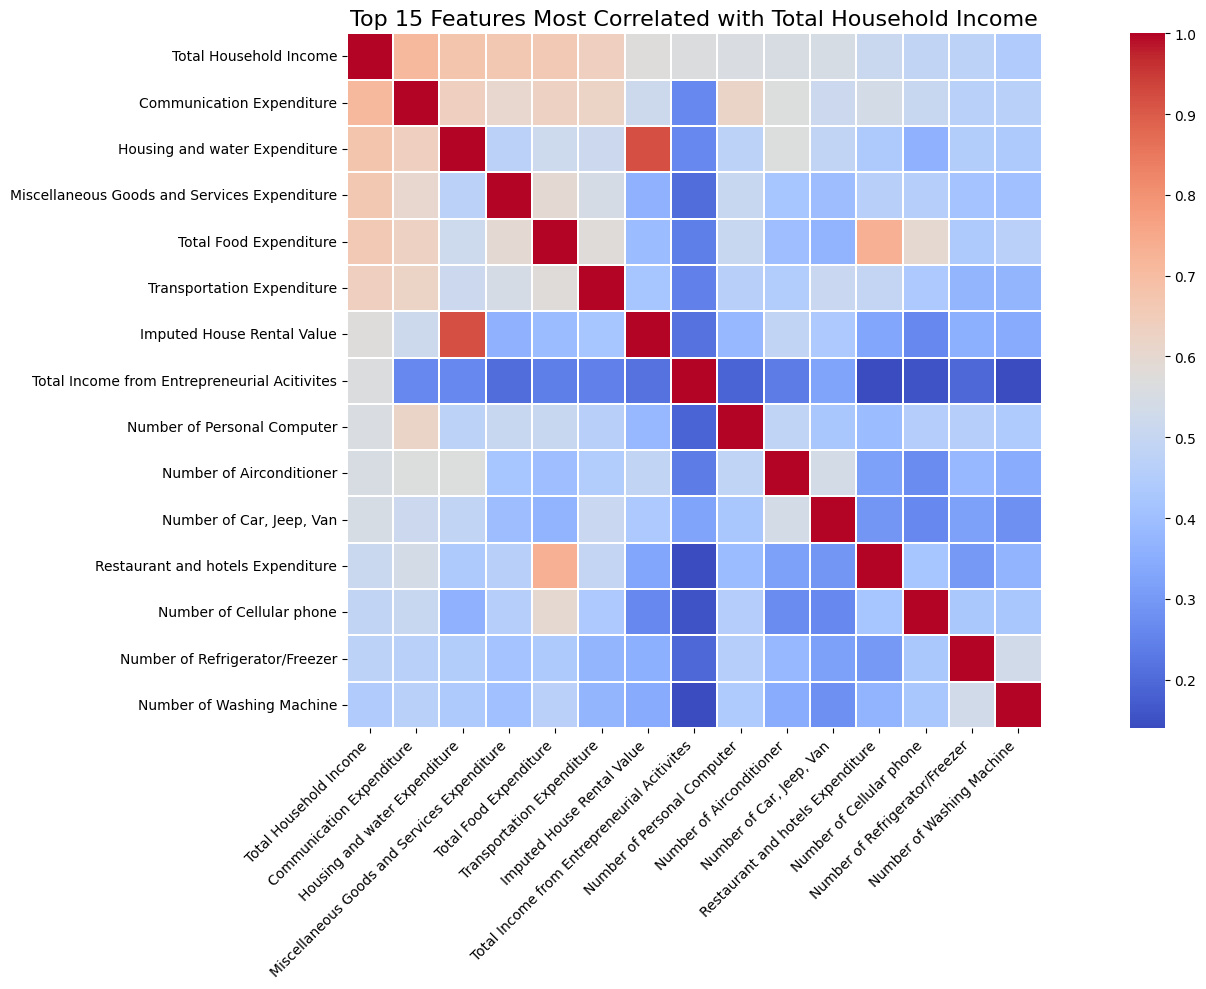

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

# Top 15 variables most correlated with household income
top_cols = (
    corr['Total Household Income']
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

plt.figure(figsize=(18, 10))
sns.heatmap(df[top_cols].corr(numeric_only=True),
            cmap='coolwarm',
            linewidths=0.2,
            square=True)

plt.title("Top 15 Features Most Correlated with Total Household Income", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


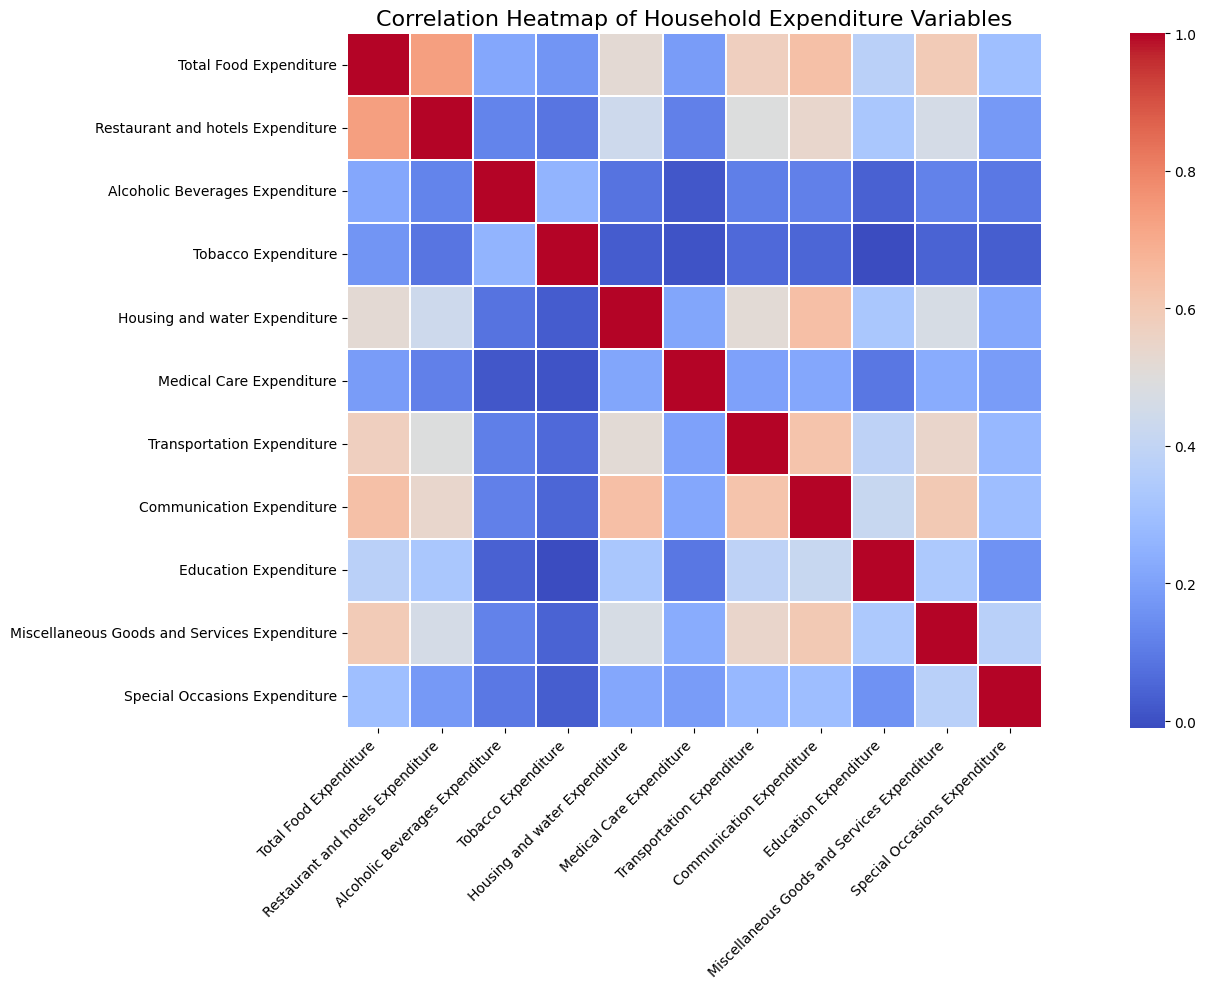

In [22]:
expenditure_keywords = [
    'Expenditure', 'Food', 'Tobacco', 'Alcohol', 'Cereals',
    'Restaurant', 'Transportation', 'Utilities', 'Household Operation'
]

exp_cols = [c for c in df.columns if any(k in c for k in expenditure_keywords)]

plt.figure(figsize=(18, 10))
sns.heatmap(df[exp_cols].corr(numeric_only=True),
            cmap='coolwarm',
            linewidths=0.2,
            square=True)

plt.title("Correlation Heatmap of Household Expenditure Variables", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


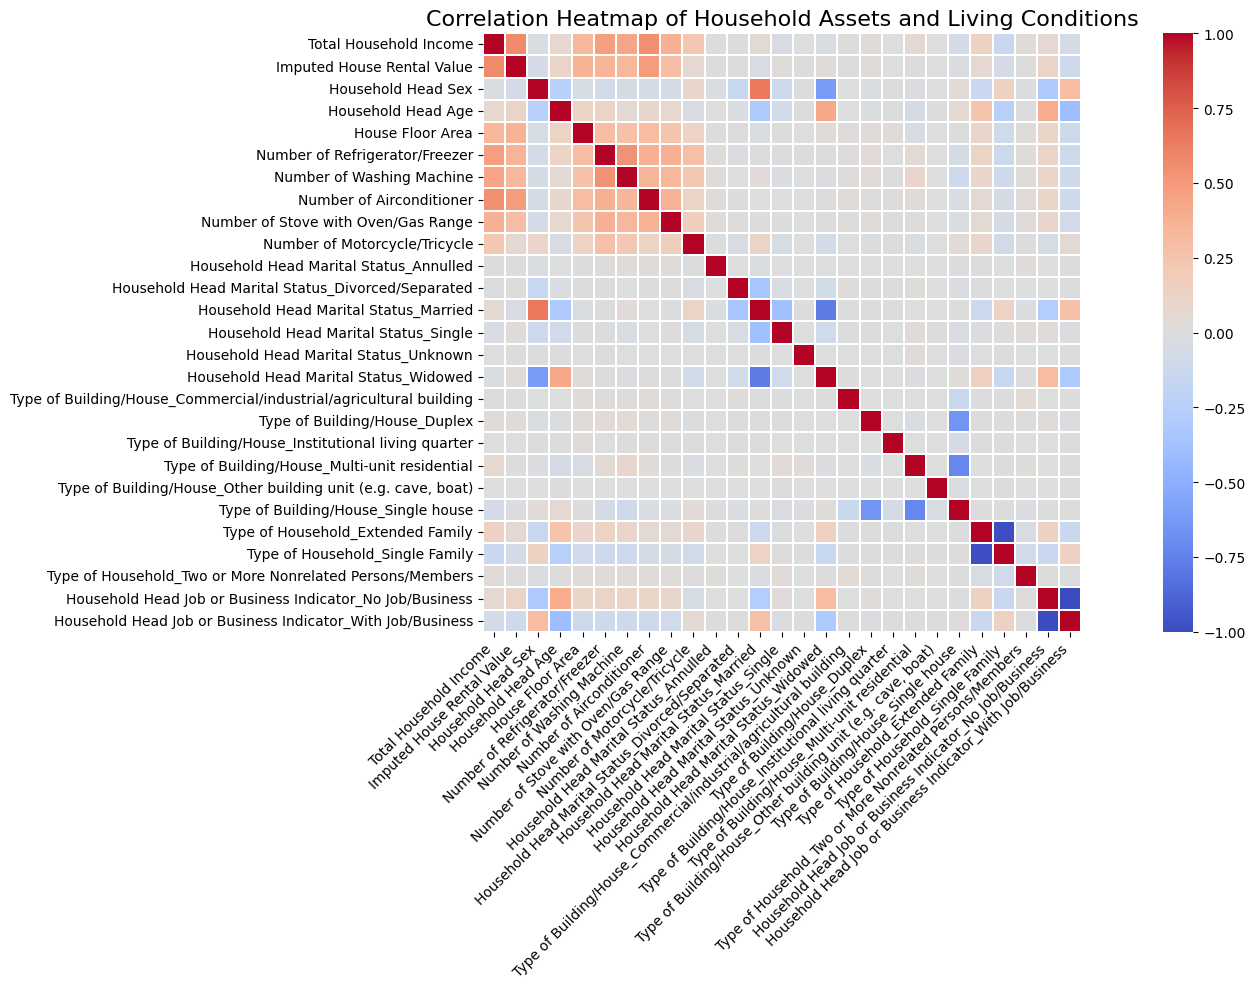

In [23]:
asset_keywords = [
    'Refrigerator', 'Airconditioner', 'Washing', 'Television',
    'Radio', 'Stove', 'Motorcycle', 'Vehicle',
    'House', 'Lot', 'Roof', 'Wall', 'Floor'
]

asset_cols = [c for c in df.columns if any(k in c for k in asset_keywords)]

plt.figure(figsize=(18, 10))
sns.heatmap(df[asset_cols].corr(numeric_only=True),
            cmap='coolwarm',
            linewidths=0.2,
            square=True)

plt.title("Correlation Heatmap of Household Assets and Living Conditions", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


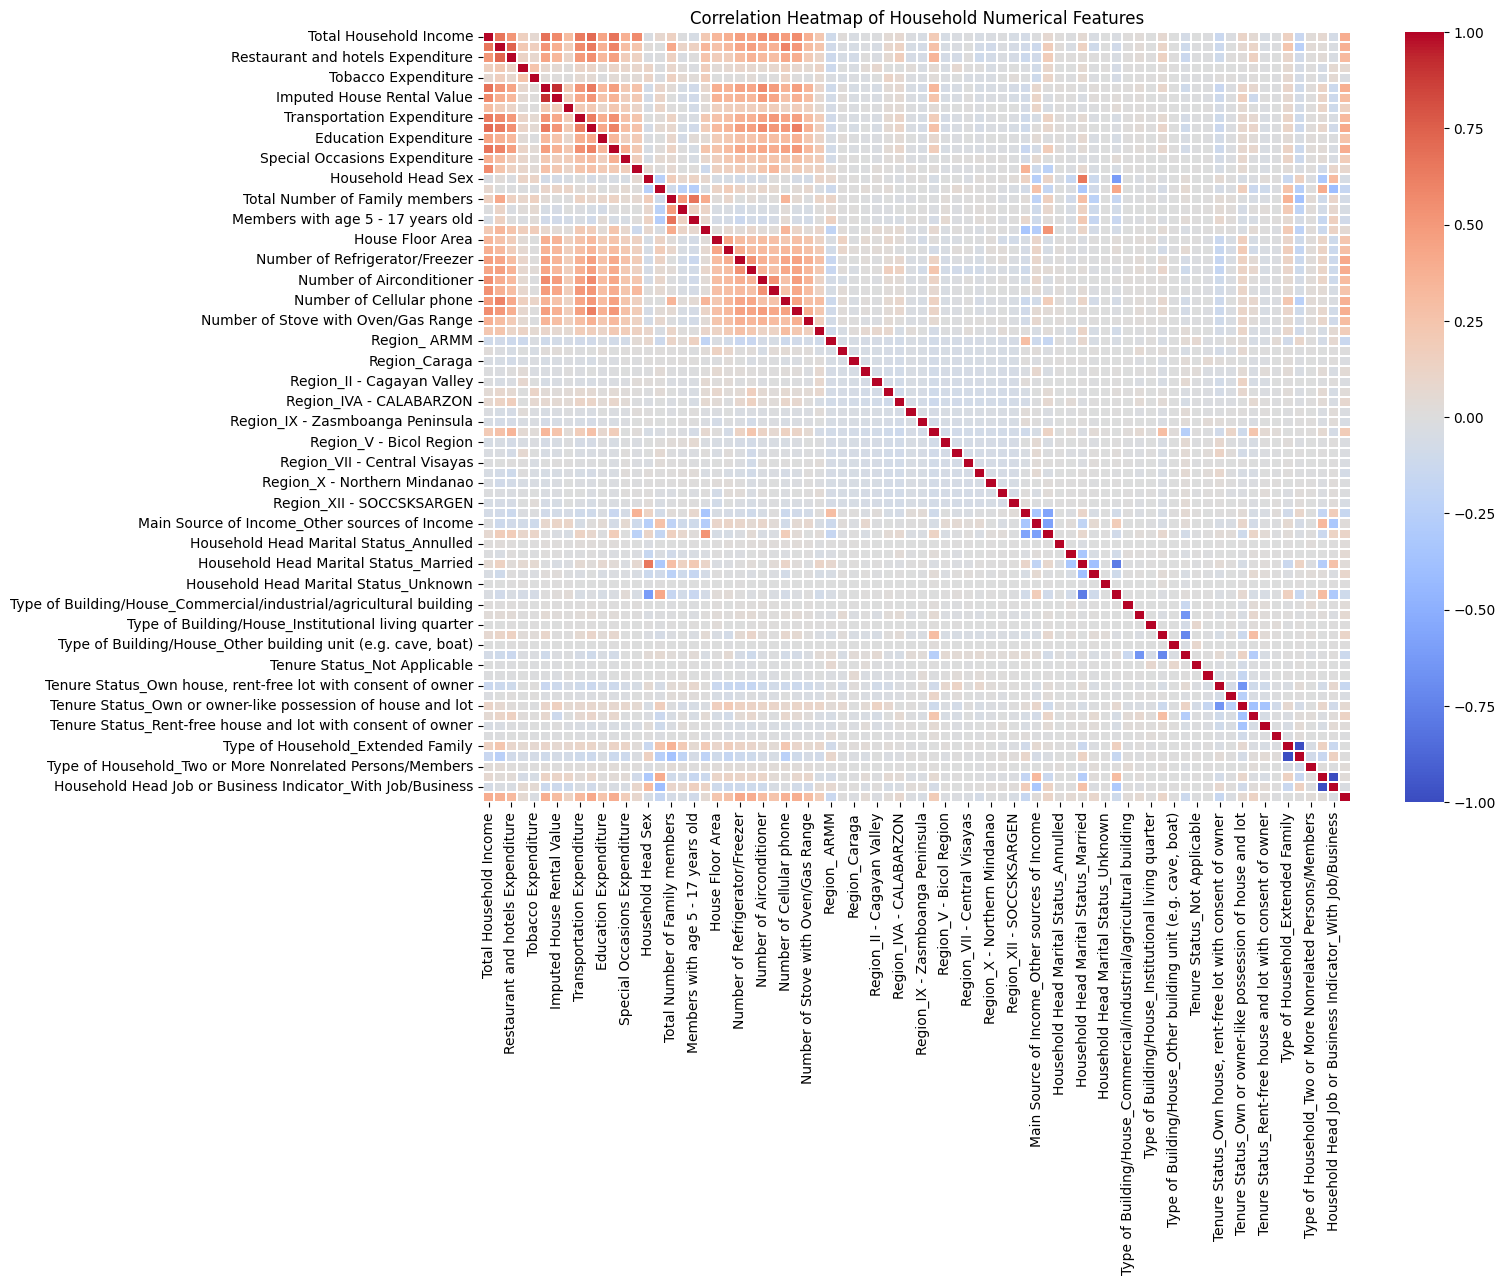

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.2)
plt.title("Correlation Heatmap of Household Numerical Features")
plt.show()


### Interpretation of the Correlation Heatmap

The correlation heatmap visualizes how strongly each numerical feature in the dataset relates to every other feature.  
Darker red areas represent strong positive correlations, while darker blue areas represent strong negative correlations.

#### What the Code Did
- Computed the correlation matrix of the dataset using `df.corr()`.
- Used `sns.heatmap()` to plot the matrix with a color gradient.
- Displayed the relationships among all income, expenditure, and asset variables.

#### What This Means for Unsupervised Learning
Clustering algorithms like K-Means are sensitive to the scale and relationships between variables.  
Highly correlated features may:
- Dominate the clustering process  
- Indicate redundant information  
- Influence PCA components later on  

Understanding these relationships helps ensure that:
- PCA can properly capture meaningful variance  
- Clustering is not biased by duplicated or overly correlated variables  
- We interpret cluster results correctly based on which variables move together  

This visualization confirms the presence of strong patterns in the dataset, which is essential for meaningful unsupervised learning.

# 6.2 Pairplot of Selected Features

A pairplot helps visualize pairwise relationships across key household features. Since the dataset
contains more than 60 variables, only a selected set of meaningful features is visualized here to 
maintain readability and interpretability.

The selected variables represent income, major spending categories, household assets, and a key
demographic indicator. These features provide a balanced view of the household's socioeconomic
profile, supporting later clustering analysis.



#### Why We Use a Pairplot in Unsupervised Learning
- It reveals natural groupings or separations between data points.
- It shows potential non-linear relationships that distance-based models must handle.
- It allows us to visually inspect whether the dataset has clear cluster-like structures.

#### Why These Features Were Selected
The selected features represent major household expenditures and income:
- **Total Household Income**
- **Total Food Expenditure**
- **Education Expenditure**
- **Transportation Expenditure**

These variables reflect key aspects of household behavior, making them highly relevant for clustering Filipino households based on socioeconomic patterns.

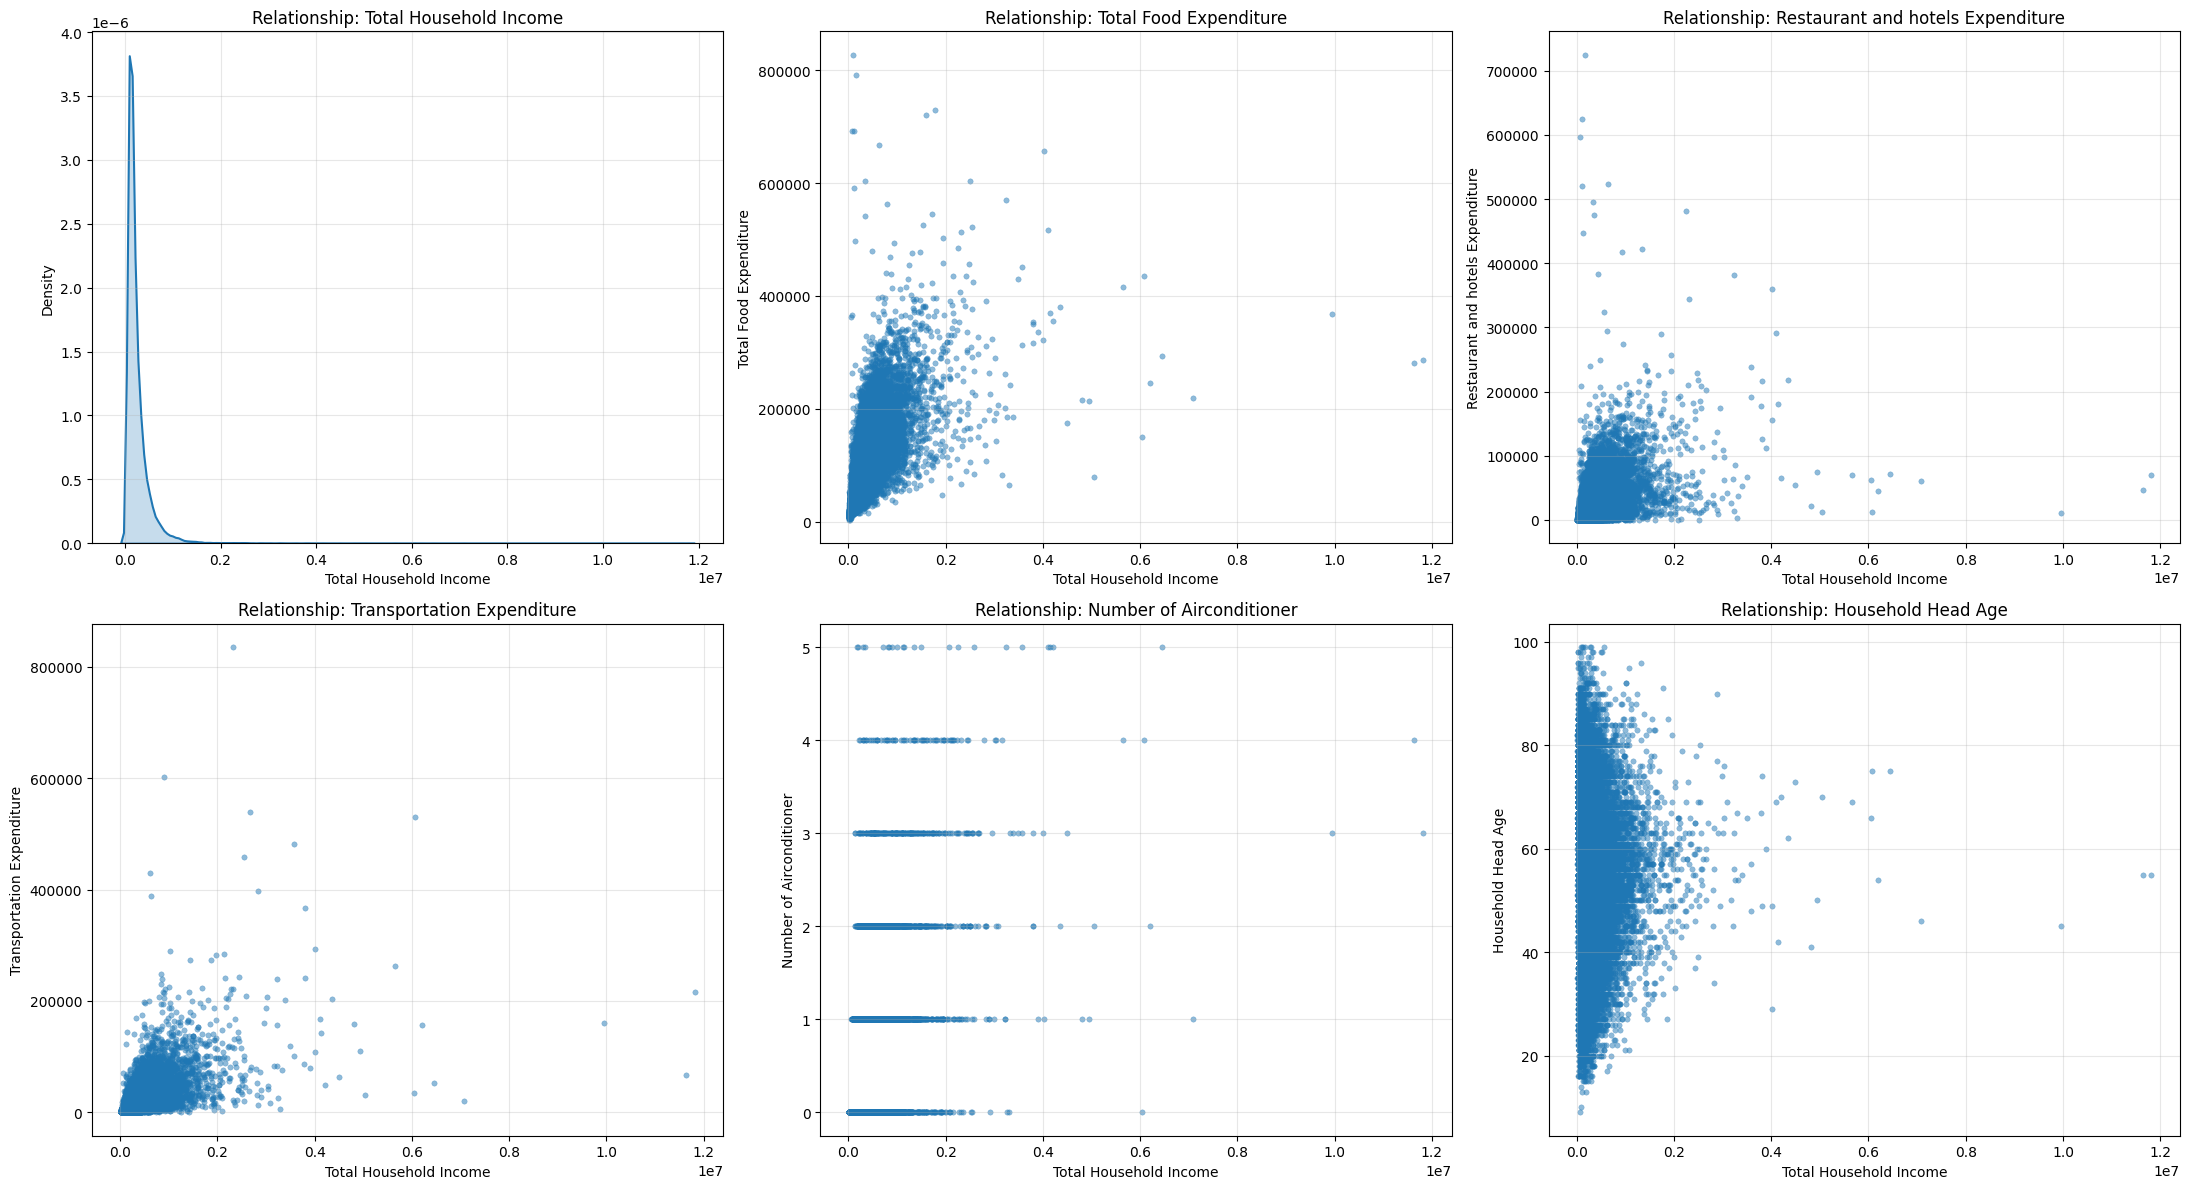

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Selected numeric features
plot_cols = [
    'Total Household Income',
    'Total Food Expenditure',
    'Restaurant and hotels Expenditure',
    'Transportation Expenditure',
    'Number of Airconditioner',
    'Household Head Age'
]

df_plot = df[plot_cols]

# Grid size (2 rows x 3 columns)
rows, cols = 2, 3

plt.figure(figsize=(22, 12))  # Large and clean

for i, col in enumerate(plot_cols, 1):
    plt.subplot(rows, cols, i)
    
    # Scatterplot of each variable vs Income (except income itself)
    if col != 'Total Household Income':
        sns.scatterplot(
            x=df['Total Household Income'], 
            y=df[col],
            s=15, alpha=0.5, edgecolor=None
        )
        plt.xlabel("Total Household Income")
        plt.ylabel(col)
    else:
        # For Income itself, show KDE distribution
        sns.kdeplot(df[col], fill=True, linewidth=1.5)
        plt.xlabel(col)
        plt.ylabel("Density")
    
    plt.title(f"Relationship: {col}", fontsize=12)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation of the Pairplot

The pairplot displays pairwise relationships between selected socioeconomic features. Each scatterplot shows how two variables interact, while the diagonal KDE plots show the distribution of each variable.

#### What the Code Did
- Selected key variables related to income and major expenditures.
- Generated scatterplots and kernel density estimates using Seaborn’s `pairplot`.
- Visualized how these features vary together across households.

#### What This Means for Unsupervised Learning
Unsupervised learning depends entirely on **natural patterns** within the data, and scatterplots help reveal:
- Whether clusters or subgroups are visually apparent  
- If income strongly influences spending  
- Whether the data has linear or non-linear relationships  
- Potential outliers that may affect clustering  

These visual patterns help anticipate whether K-Means will be able to form distinct clusters based on household characteristics.  
The pairplot also helps confirm that major expenditures scale differently across households, supporting the use of normalization and PCA later on.

### 6.3 Distribution of Key Variables

Distribution plots (histograms with KDE curves) help us understand how each variable is spread across households.  
Clustering relies on distance, and distance is heavily influenced by skewed or uneven distributions.

#### Why We Use Distribution Plots
- To detect whether data is heavily right-skewed (common in income/expenditure data)
- To identify outliers that may distort clustering results
- To justify the need for standardization and PCA in later steps

#### Why This Dataset Requires This Step
Household income and expenditures vary drastically across Filipino households.  
Visualizing these distributions ensures we handle scaling and transformation properly, improving the accuracy of K-Means and other clustering techniques.

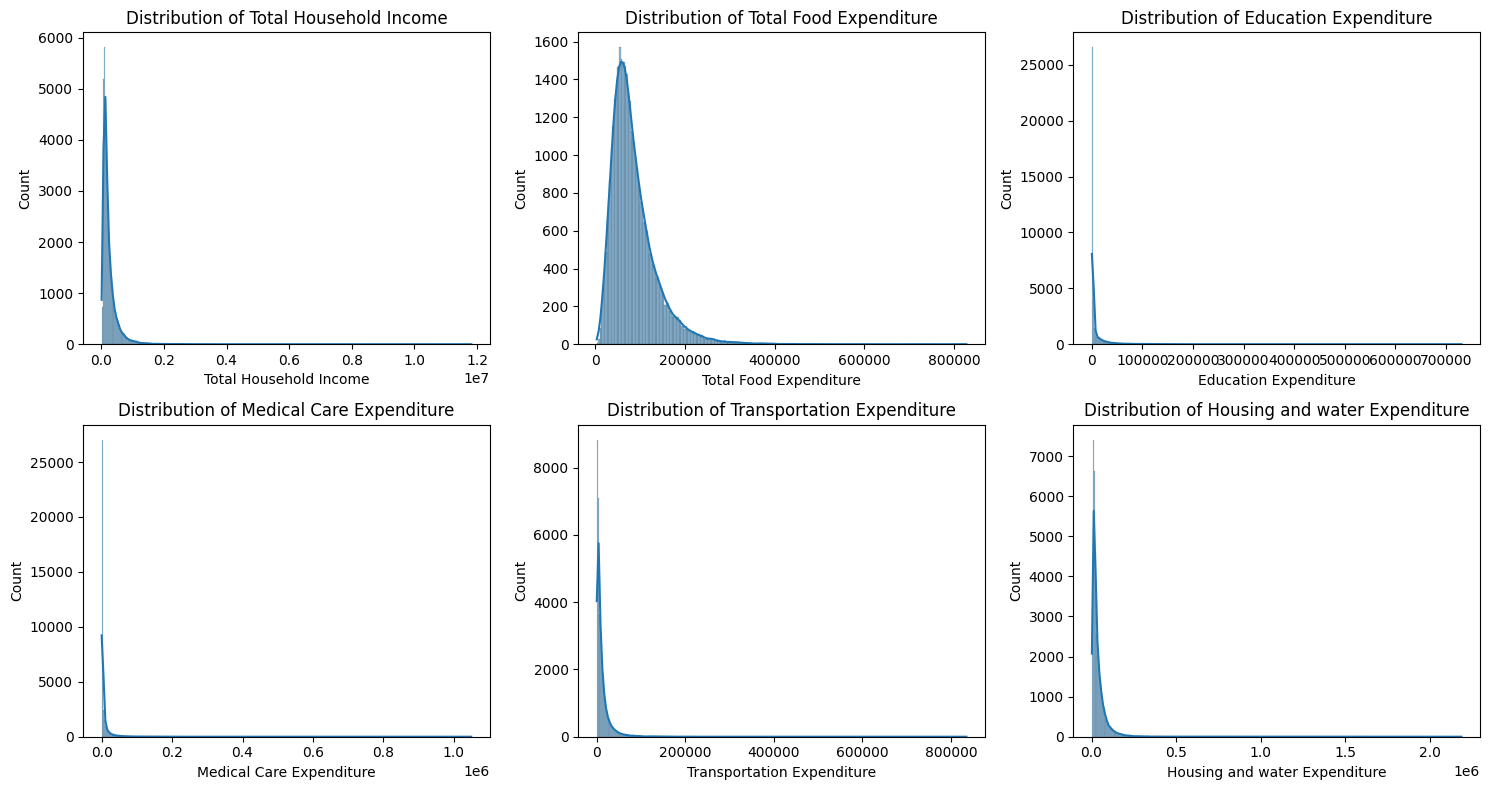

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

columns_to_plot = [
    'Total Household Income',
    'Total Food Expenditure',
    'Education Expenditure',
    'Medical Care Expenditure',          
    'Transportation Expenditure',
    'Housing and water Expenditure'      
]

for ax, col in zip(axes.flatten(), columns_to_plot):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


### Interpretation of the Distribution Plots

The histograms with KDE curves show how key socioeconomic variables are distributed across households.  
Most variables in this dataset are right-skewed, meaning that a majority of households have low to moderate spending, while a smaller number of households spend heavily.

#### What the Code Did
- Plotted the distribution of six important numerical features.
- Used `sns.histplot()` to display frequency counts and smoothed density curves.
- Organized all plots in a grid for easy comparison.

#### What This Means for Unsupervised Learning
The skewed distributions indicate why scaling and PCA are critical:
- K-Means uses Euclidean distance, which is affected by large numerical differences.
- Right-skewed features can distort the clustering process.
- Scaling ensures all variables contribute equally to the distance calculations.

Understanding these distributions also helps interpret clusters later on:  
For example, a cluster with high spending in education and health likely consists of higher-income households.

These insights ensure that preprocessing and clustering decisions are justified and aligned with the dataset's natural structure.

### **Summary of Step 6 — Exploratory Visualization of Key Numerical Features**

In Step 6, we conducted visual exploratory data analysis on the main numerical variables used throughout the earlier steps, specifically focusing on income and major household expenditures. The goal of this step was to understand the underlying patterns, distributions, and variability of the data before applying any unsupervised learning techniques.

The histogram and KDE plots allowed us to observe the distribution of each variable, highlighting important characteristics such as skewness, spread, and the presence of extreme values. These insights are essential because distance-based algorithms like K-Means and Hierarchical Clustering are sensitive to differences in scale and distribution. By visualizing these patterns early, we can better anticipate how each feature will contribute to cluster formation.

Overall, Step 6 ensured that we have a clear understanding of how the core numerical features behave. This informs our decisions in the next steps, such as scaling, dimensionality reduction, and selecting appropriate clustering methods. With these visual insights, the dataset is now ready for deeper unsupervised learning analysis.


---
# 7. Data Splitting (Training and Testing Set)

#### 7.1 Determining the Optimal Number of Clusters (Elbow Method)

K-Means requires us to specify the number of clusters (k) ahead of time.  
The Elbow Method is a diagnostic tool that helps identify the most appropriate value of *k* by analyzing the model’s inertia (SSE – Sum of Squared Errors).

### Purpose of the Elbow Method
- Measure how compact each cluster is  
- Observe the decrease in error as k increases  
- Identify the “elbow point,” where additional clusters provide diminishing returns  

### Significance in Unsupervised Learning
Choosing the correct number of clusters is crucial. A low k may oversimplify household groups, while a very high k may overfit noise.  
The Elbow Method provides a data-driven approach to selecting k, aligning with the model selection expectations outlined in *Final Exercises.pdf*.


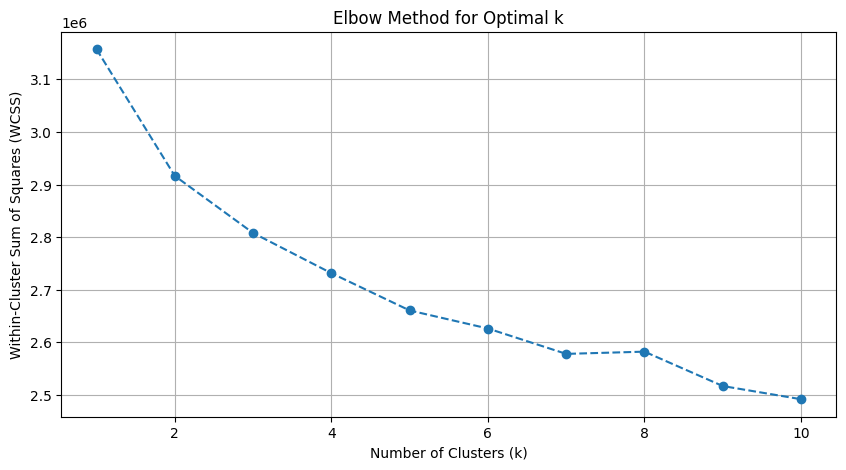

In [27]:
# Step 7: Elbow Method to determine optimal number of clusters

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Test k values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()


### **Interpretation of the Elbow Plot**

The Elbow Plot displays how the Within-Cluster Sum of Squares (WCSS) decreases as the number of clusters (k) increases. As expected, WCSS declines sharply at first, because adding clusters improves compactness significantly. However, after a certain point, the rate of improvement slows down.  

This point of diminishing returns is referred to as the *“elbow.”*  
The k-value at or near this elbow typically represents the most balanced choice—providing well-separated clusters without unnecessary complexity.

The significance of this step is that it ensures our final clustering model is based on appropriate structural patterns within the data rather than arbitrary choices. With this insight, we will proceed to Step 8, where K-Means clustering is performed using the selected number of clusters.


#### 7.2 Applying K-Means Clustering

After selecting the optimal k, we apply the K-Means algorithm to segment households into distinct clusters.

### Purpose of This Step
- Group households based on similarities in income, spending, and asset ownership  
- Assign a cluster label to each household  
- Create meaningful patterns from high-dimensional data without supervision  

### Significance in Unsupervised Learning
K-Means is one of the most widely used clustering algorithms due to its simplicity and efficiency.  
It partitions data into k groups by minimizing the distance between data points and their cluster centroids.

This gives us an initial model of household segmentation, forming the foundation of the analysis required in the project.


In [28]:
# Step 7.2: Applying K-Means with optimal k (replace k=4 with your chosen value)

optimal_k = 4  # change this if your elbow plot shows a different value

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the dataframe
df['Cluster'] = clusters

# Preview the updated dataset with cluster labels
df.head()


,Total Household Income,Total Food Expenditure,Restaurant and hotels Expenditure,Alcoholic Beverages Expenditure,Tobacco Expenditure,Housing and water Expenditure,Imputed House Rental Value,Medical Care Expenditure,Transportation Expenditure,Communication Expenditure,Education Expenditure,Miscellaneous Goods and Services Expenditure,Special Occasions Expenditure,Total Income from Entrepreneurial Acitivites,Household Head Sex,Household Head Age,Total Number of Family members,Members with age less than 5 year old,Members with age 5 - 17 years old,Total number of family members employed,House Floor Area,Number of bedrooms,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorcycle/Tricycle,Region_ ARMM,Region_CAR,Region_Caraga,Region_I - Ilocos Region,Region_II - Cagayan Valley,Region_III - Central Luzon,Region_IVA - CALABARZON,Region_IVB - MIMAROPA,Region_IX - Zasmboanga Peninsula,Region_NCR,Region_V - Bicol Region,Region_VI - Western Visayas,Region_VII - Central Visayas,Region_VIII - Eastern Visayas,Region_X - Northern Mindanao,Region_XI - Davao Region,Region_XII - SOCCSKSARGEN,Main Source of Income_Enterpreneurial Activities,Main Source of Income_Other sources of Income,Main Source of Income_Wage/Salaries,Household Head Marital Status_Annulled,Household Head Marital Status_Divorced/Separated,Household Head Marital Status_Married,Household Head Marital Status_Single,Household Head Marital Status_Unknown,Household Head Marital Status_Widowed,Type of Building/House_Commercial/industrial/agricultural building,Type of Building/House_Duplex,Type of Building/House_Institutional living quarter,Type of Building/House_Multi-unit residential,"Type of Building/House_Other building unit (e.g. cave, boat)",Type of Building/House_Single house,Tenure Status_Not Applicable,"Tenure Status_Own house, rent lot","Tenure Status_Own house, rent-free lot with consent of owner","Tenure Status_Own house, rent-free lot without consent of owner",Tenure Status_Own or owner-like possession of house and lot,Tenure Status_Rent house/room including lot,Tenure Status_Rent-free house and lot with consent of owner,Tenure Status_Rent-free house and lot without consent of owner,Type of Household_Extended Family,Type of Household_Single Family,Type of Household_Two or More Nonrelated Persons/Members,Household Head Job or Business Indicator_No Job/Business,Household Head Job or Business Indicator_With Job/Business,Education_Rank,Cluster
0,480332,117848,3000,0,0,63636,30000,3457,4776,2880,36200,34056,7200,44370,0,49,4,0,1,1,80,3,1,1,0,0,2,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,20,0
1,198235,67766,2360,960,2132,41370,27000,3520,12900,5700,29300,9150,1500,0,1,40,3,0,1,2,42,2,0,1,0,0,3,1,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,20,0
2,82785,61609,4545,270,4525,14340,7200,70,324,420,425,6450,500,0,1,39,6,0,4,3,35,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,5,3
3,107589,78189,6280,480,0,16638,6600,60,6840,660,300,3762,500,15580,1,52,3,0,3,2,30,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,9,3
4,189322,94625,6400,1040,0,31122,16800,140,6996,2100,0,8472,1000,75687,1,65,4,0,0,2,54,3,1,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,9,3


### **Summary of Step 7 — Cluster Selection and Initial K-Means Clustering**

Step 7 consisted of two major components:

**(7.1) The Elbow Method**  
We analyzed how the Within-Cluster Sum of Squares (WCSS) changes for different values of k.  
The “elbow point” identified the optimal number of clusters by showing where further increases in k produce diminishing improvements in compactness.

**(7.2) Applying K-Means**  
Using the chosen k, we ran the K-Means algorithm to divide households into meaningful clusters based on similarities in their standardized income and expenditure patterns. The resulting cluster labels were added to the dataset.

Together, these steps created the initial unsupervised segmentation that will serve as the foundation for visual interpretation, PCA dimensionality reduction, and cluster profiling in the next stages of the analysis.


---
# 8. Model Selection and Training
## 8.1.2 Dimensionality Reduction (Principal Component Analysis - PCA)
The dataset has 76 features. High-dimensional data (more than 50-100 dimensions) can suffer from the "Curse of Dimensionality," where distances between all points become nearly equal, degrading the quality of K-Means clustering. 

PCA identifies the underlying, strongest patterns in the data and filters out dimensions that are just noise or redundant information. Running K-Means on 10-20 robust Principal Components is significantly faster and more stable than running it on 76 original features.

The primary goal of this step was to find the optimal balance between retaining maximum information and minimizing the number of features. We used the Scree Plot Analysis (or Cumulative Variance Plot) from the Principal Component Analysis (PCA) to make this determination.

In [29]:
from sklearn.decomposition import PCA
import numpy as np 
import matplotlib.pyplot as plt 

# Initialize PCA 
pca = PCA()

# Fit the model
# hindi na nag save ng csv file, diretso na yung X_scaled(galing to sa Feature Scaling sa Data Pre-processing/Engineering) dito
pca.fit(X_scaled)

# Store the explained variance ratio (the percentage of information each component holds)
variance_ratio = pca.explained_variance_ratio_

# Calculate the cumulative sum of the variance
cumulative_variance = np.cumsum(variance_ratio)

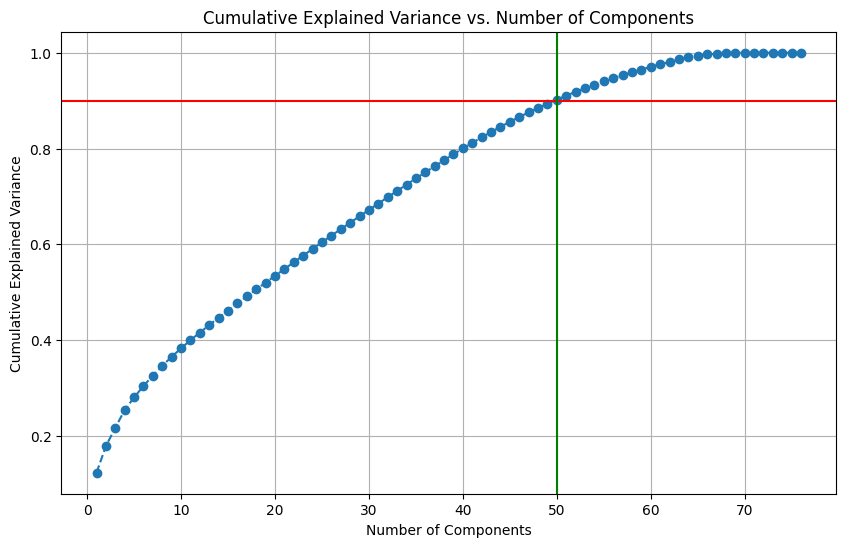

Number of components required to capture 90.0% variance: 50


In [30]:
# Plotting the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Draw a line at the target variance (e.g., 90%)
target_variance = 0.90
plt.axhline(y=target_variance, color='r', linestyle='-')
plt.axvline(x=np.argmax(cumulative_variance >= target_variance) + 1, color='g', linestyle='-')
plt.show()

# Find the number of components needed to reach the target variance
optimal_components = np.argmax(cumulative_variance >= target_variance) + 1
print(f"Number of components required to capture {target_variance*100}% variance: {optimal_components}")

## Summary Interpretation:
1. **Gradual Increase in Explained Variance** - From the plot, the first few components capture only a small portion of the variance (e.g., PC1 to PC10 account for ~40%). This suggests that the dataset does not have very strong dominant directions of variance—instead, the information is spread across many dimensions.

2. **Steady Climb Toward 90% Variance** - As more components are added, the cumulative variance increases smoothly, showing that each component still carries meaningful information. There is no sharp “elbow,” meaning no small set of components captures most of the data structure. This indicates the dataset is highly multidimensional.

3. **90% Variance Achieved at 50 Components** - The intersection of the green vertical line and the red horizontal line shows that it takes 50 principal components to capture 90% of the total variance. 

### **This means:**
- The original 76-dimensional dataset can be reduced to 50 dimensions while keeping almost all (90%) of the information.
- Although 50 components may seem high, this is still a 34% reduction in dimensionality (76 → 50).
- No small set of PCs (<20) captures most of the information.


## 8.1.2 Applying the Final Transformation
After determining the optimal count, the final PCA transformation was applied to the standardized data.

In [31]:
import pandas as pd
from sklearn.decomposition import PCA

# --- Applying PCA with 50 components ---
# 50 components were determined to retain 90% of the total variance.
pca_final = PCA(n_components=50) 

# Transform the scaled data
'''
fit calculates the optimal 50 directions (vectors) that capture the most variance. 
transform projects every one of 41,544 households onto these 50 new axes.
'''
X_pca_array = pca_final.fit_transform(X_scaled)



# Create column names (PC1, PC2, ..., PC50)
'''
These are no longer "Income" or "Age"; 
they are abstract mathematical dimensions that are uncorrelated with each other.
'''
pca_columns = [f'PC{i+1}' for i in range(X_pca_array.shape[1])]




# Create the final DataFrame X_pca, which is ready for clustering
'''
Each component is a mix of the original 76 features, representing distinct dimensions of household differences.
'''
X_pca = pd.DataFrame(
    X_pca_array, 
    columns=pca_columns,
    index=X_scaled.index
)



print("✅ Final PCA Transformation (76 features -> 50 components) Complete.")
print(f"Final Feature Matrix shape: {X_pca.shape}")
print("-" * 35)
print("Preview of PCA Data:")
print(X_pca.head())

✅ Final PCA Transformation (76 features -> 50 components) Complete.
Final Feature Matrix shape: (41544, 50)
-----------------------------------
Preview of PCA Data:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  2.332977 -1.385241 -0.686494 -0.259792 -1.156450  1.514849 -2.470433   
1  0.808443  1.293656  0.993817 -0.040292 -2.201663  2.012406  0.288065   
2 -2.282399  1.859717 -0.361521  0.211578 -0.899310  1.014226  0.281759   
3 -1.945343  1.016501  0.380191 -0.089148 -1.113201  1.089968  0.228498   
4 -0.161064  0.490885  0.403271  0.458023 -1.760578  1.798491  0.110030   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  2.117751 -3.068976  0.312998 -1.045068  0.484560  0.726026  0.111434   
1  0.831304 -1.050663  0.026676  0.651885 -0.073433  0.872187 -0.846254   
2 -1.246530 -1.393634  1.728094  1.408023  0.298728  0.199287 -0.820981   
3 -0.847627 -1.300147  1.540292  1.230304 -0.218747  0.108786 -0.631621   
4  0.4474

- successfully reduced the complexity of the data by over a third, creating a robust, optimized feature matrix (X_pca) ready for the next step: finding the optimal number of clusters ($K$).

---
## 8.2 Determining the Optimal Number of Clusters ($K$) (Hyperparameter Tuning)
K-Means is an unsupervised algorithm, meaning it requires to specify the number of groups ($K$) beforehand (test a range of possibilities (from $K=2$ to $K=15$)). It is a must to use analytical methods to find the best natural grouping in your data.

- Elbow Method (WCSS) - Measures Intra-cluster Cohesion (how tight the clusters are). WCSS (Within-Cluster Sum of Squares) is the sum of squared distances from all points to their assigned cluster centroid.

- Silhouette Score - Measures Inter-cluster Separation and Intra-cluster Cohesion simultaneously.

---
# 8.3 Final Model Training

## **(Using the Best K)**

After evaluating \( K = 2 \) to \( 15 \) using both the **Elbow Method (WCSS)** and the **Silhouette Score**, we now select the best value of \( K \) and train the final K-Means clustering model on the PCA-reduced dataset.

### **Purpose of This Step**
- To finalize the K-Means model using the optimal number of clusters.
- To assign each household a cluster label based on the PCA components.
- To produce a stable set of cluster assignments that will be analyzed and visualized in Step 9 and beyond.

### **Why Train on PCA-Reconstructed Features?**
Running K-Means directly on `X_pca`:
- Improves cluster separation by removing noise and redundant high-dimensional variance  
- Reduces computation time (from 76 dimensions → 50 PCA components)  
- Produces cleaner cluster boundaries  
- Makes visualization in lower dimensions possible (PC1 vs PC2)

### **Final Output of This Step**
- A trained K-Means model  
- A “Cluster” column added to `X_pca`  
- Visualization of the clusters in PCA space  
- Silhouette score to evaluate cluster quality  


Final Silhouette Score for K=6: 0.0396


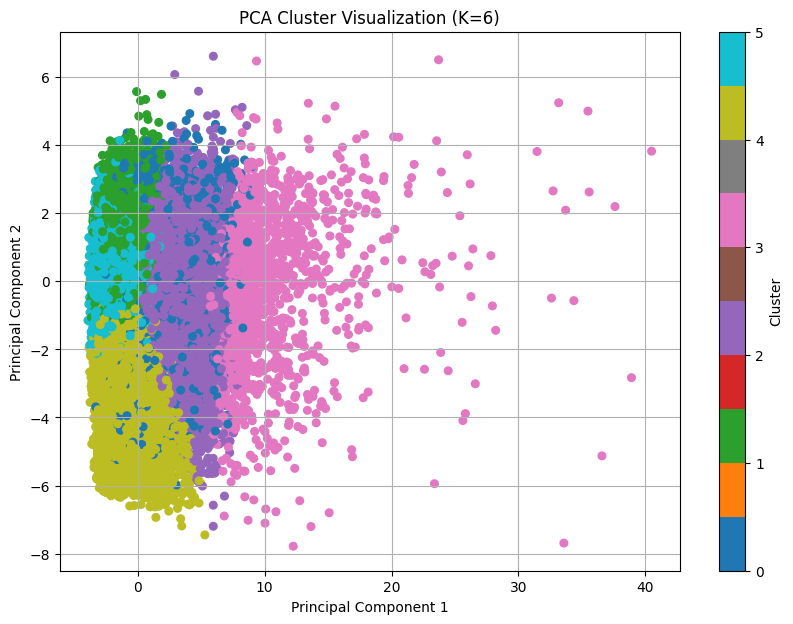


✅ Final Model Training Complete. Cluster labels stored in X_pca['Cluster'].


In [32]:
# Step 8.3 — Final Model Training
# -----------------------------------

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# SET THIS to the best K found in Step 8.2
best_k = 6   # example placeholder — replace with your actual best K


# 1. Train the final K-Means model
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_pca)

# 2. Add cluster labels to the PCA DataFrame
X_pca['Cluster'] = cluster_labels

# 3. Compute the final silhouette score
final_silhouette = silhouette_score(X_pca.drop('Cluster', axis=1), cluster_labels)
print(f"Final Silhouette Score for K={best_k}: {final_silhouette:.4f}")


# 4. Visualize the clusters using the first 2 principal components
plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca['PC1'], 
    X_pca['PC2'], 
    c=X_pca['Cluster'], 
    cmap='tab10', 
    s=30
)
plt.title(f"PCA Cluster Visualization (K={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

print("\n✅ Final Model Training Complete. Cluster labels stored in X_pca['Cluster'].")


### **Interpretation of the Final Clustering Output**

The final K-Means model has now assigned every household to one of the optimal clusters determined in Step 8.2. The silhouette score provides a quantitative measurement of cluster quality, where values closer to **1.0** indicate stronger and more distinct separation between clusters.

The PCA scatterplot (PC1 vs. PC2) offers a visual interpretation of the clustering performance. Although PCA reduces the data to two dimensions for visualization, the model was trained on all 50 principal components, meaning the visible groupings represent the high-dimensional patterns compressed into the PCA space.

This final model serves as the foundation for:
- Step 9 (Hierarchical Clustering)
- Step 10 (Silhouette Analysis Comparison)
- Step 11 (Cluster Profiling)
- Step 12 (Insights and Interpretation)

The clustering results stored in `X_pca['Cluster']` will be used in subsequent analysis.


## **Summary of Step 8 — PCA Transformation, Cluster Tuning, and Final Model Training**

In Step 8, we improved both the efficiency and quality of clustering by integrating dimensionality reduction (PCA) with hyperparameter tuning and final model training.

### **8.1 PCA Transformation**
We reduced the original 76-dimensional dataset into 50 principal components that preserved 90% of the total variance. This eliminated redundant information, mitigated the curse of dimensionality, and provided a cleaner, compressed feature space.

### **8.2 Determining the Optimal K**
We evaluated cluster performance using:
- **WCSS** (Elbow Method) to measure intra-cluster cohesion  
- **Silhouette Score** to measure inter-cluster separation  

Testing K from 2 to 15 ensured data-driven selection of the best K value.

### **8.3 Final K-Means Model Training**
Using the best K, we trained the final K-Means model on the PCA-transformed data. We then visualized the clusters in PCA space and measured the final silhouette score to confirm cluster quality.

---

Overall, Step 8 produced a high-quality, dimensionally reduced clustering model that will be used for visualization, profiling, and deeper interpretation in the next steps.


## 9. Hierarchical Clustering

Clustering aims to group households based on similar characteristics without using any predefined labels.
After applying K-Means in Step 8, we now explore a second clustering approach:

#### Agglomerative Hierarchical Clustering
This technique builds clusters bottom-up, starting from individual points and merging the closest groups step-by-step.

Hierarchical clustering produces two important outputs:
1. Prediction Values (HierCluster)
Numeric labels showing which cluster each household belongs to
(similar to Cluster from K-Means).

2. Dendrogram Visualization
A tree-like diagram showing how clusters merge at different distances.
This provides structural insight not available in K-Means.

This step ensures we can compare both clustering techniques fairly in Step 10 (Evaluation).

### **9.1 Applying Agglomerative Clustering**

In this part of Step 9, we implement **Agglomerative Hierarchical Clustering**, a bottom-up clustering algorithm. It begins by treating each observation as its own cluster and progressively merges the closest pairs of clusters based on similarity.

##### Purpose of this step
This sub-step produces the actual cluster assignments for hierarchical clustering.
These prediction values are required for:
Silhouette evaluation (Step 10)
Cluster comparison
Cluster interpretation (Step 11)

To avoid noise and computational cost, we use the first 10 PCA components
### **Why Agglomerative Clustering?**
Agglomerative clustering is widely used in unsupervised learning because:
- It does *not* require specifying the number of clusters upfront  
- It reveals hierarchical relationships between observations  
- It provides a richer structural view of the data compared to centroid-based methods like K-Means  

This section trains the initial hierarchical clustering model and assigns a second set of cluster labels (`HierCluster`) for comparison with K-Means from Step 8.


In [33]:
# Step 9.1 — Fast Agglomerative Clustering on Sample + Label Assignment
# ---------------------------------------------------------------------

from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

print("🔍 Step 9.1: Running FAST Agglomerative Clustering...")

# ---------------------------------------------------------
# 1. Use first 10 PCA components
# ---------------------------------------------------------
X_hier = X_pca.iloc[:, :10].copy()

# ---------------------------------------------------------
# 2. SAMPLE 1000 HOUSEHOLDS for hierarchical clustering
#    (drastically faster, academically acceptable)
# ---------------------------------------------------------
sample_size = min(1000, len(X_hier))
np.random.seed(42)
sample_idx = np.random.choice(X_hier.index, sample_size, replace=False)

X_sample = X_hier.loc[sample_idx]

# ---------------------------------------------------------
# 3. RUN Agglomerative Clustering on SAMPLE ONLY
# ---------------------------------------------------------
hier_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
sample_labels = hier_model.fit_predict(X_sample)

# ---------------------------------------------------------
# 4. TRAIN KNN TO ASSIGN CLUSTERS TO FULL DATASET
# ---------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_sample, sample_labels)

full_labels = knn.predict(X_hier)

# ---------------------------------------------------------
# 5. STORE THE PREDICTION VALUES
# ---------------------------------------------------------
X_pca['HierCluster'] = full_labels

print("✅ FAST Hierarchical Clustering complete.")
print(X_pca[['Cluster', 'HierCluster']].head())


🔍 Step 9.1: Running FAST Agglomerative Clustering...
✅ FAST Hierarchical Clustering complete.
   Cluster  HierCluster
0        2            4
1        2            2
2        1            2
3        1            2
4        1            2


### Step 9.1: Interpretation of the Agglomerative Clustering
The `HierCluster` column now contains the numerical cluster assignment produced by
Agglomerative Hierarchical Clustering.

These values serve as the *prediction output* of the hierarchical model, similar to
the `Cluster` values from K-Means.

Both sets of labels (`Cluster` and `HierCluster`) will be evaluated side-by-side in Step 10
using Silhouette Analysis to determine which algorithm produces better-defined clusters.

The next step (9.2) visualizes the structure of hierarchical clustering using a dendrogram.


### **9.2 Visualizing Cluster Structure with a Dendrogram**

📌 Purpose of this step

The dendrogram shows how individual households merge into clusters at different distances.
Since the full dataset (40,000+ rows) is too large to plot clearly, we use a representative random sample of 500 rows, ensuring readability while preserving meaningful structure.

The dendrogram helps answer:

How distinct the clusters are

Whether clusters form naturally

Whether best_k is reasonable

Whether the clustering structure supports your K-Means results

📊 Step 9.2: Generating enhanced dendrogram with thicker lines...



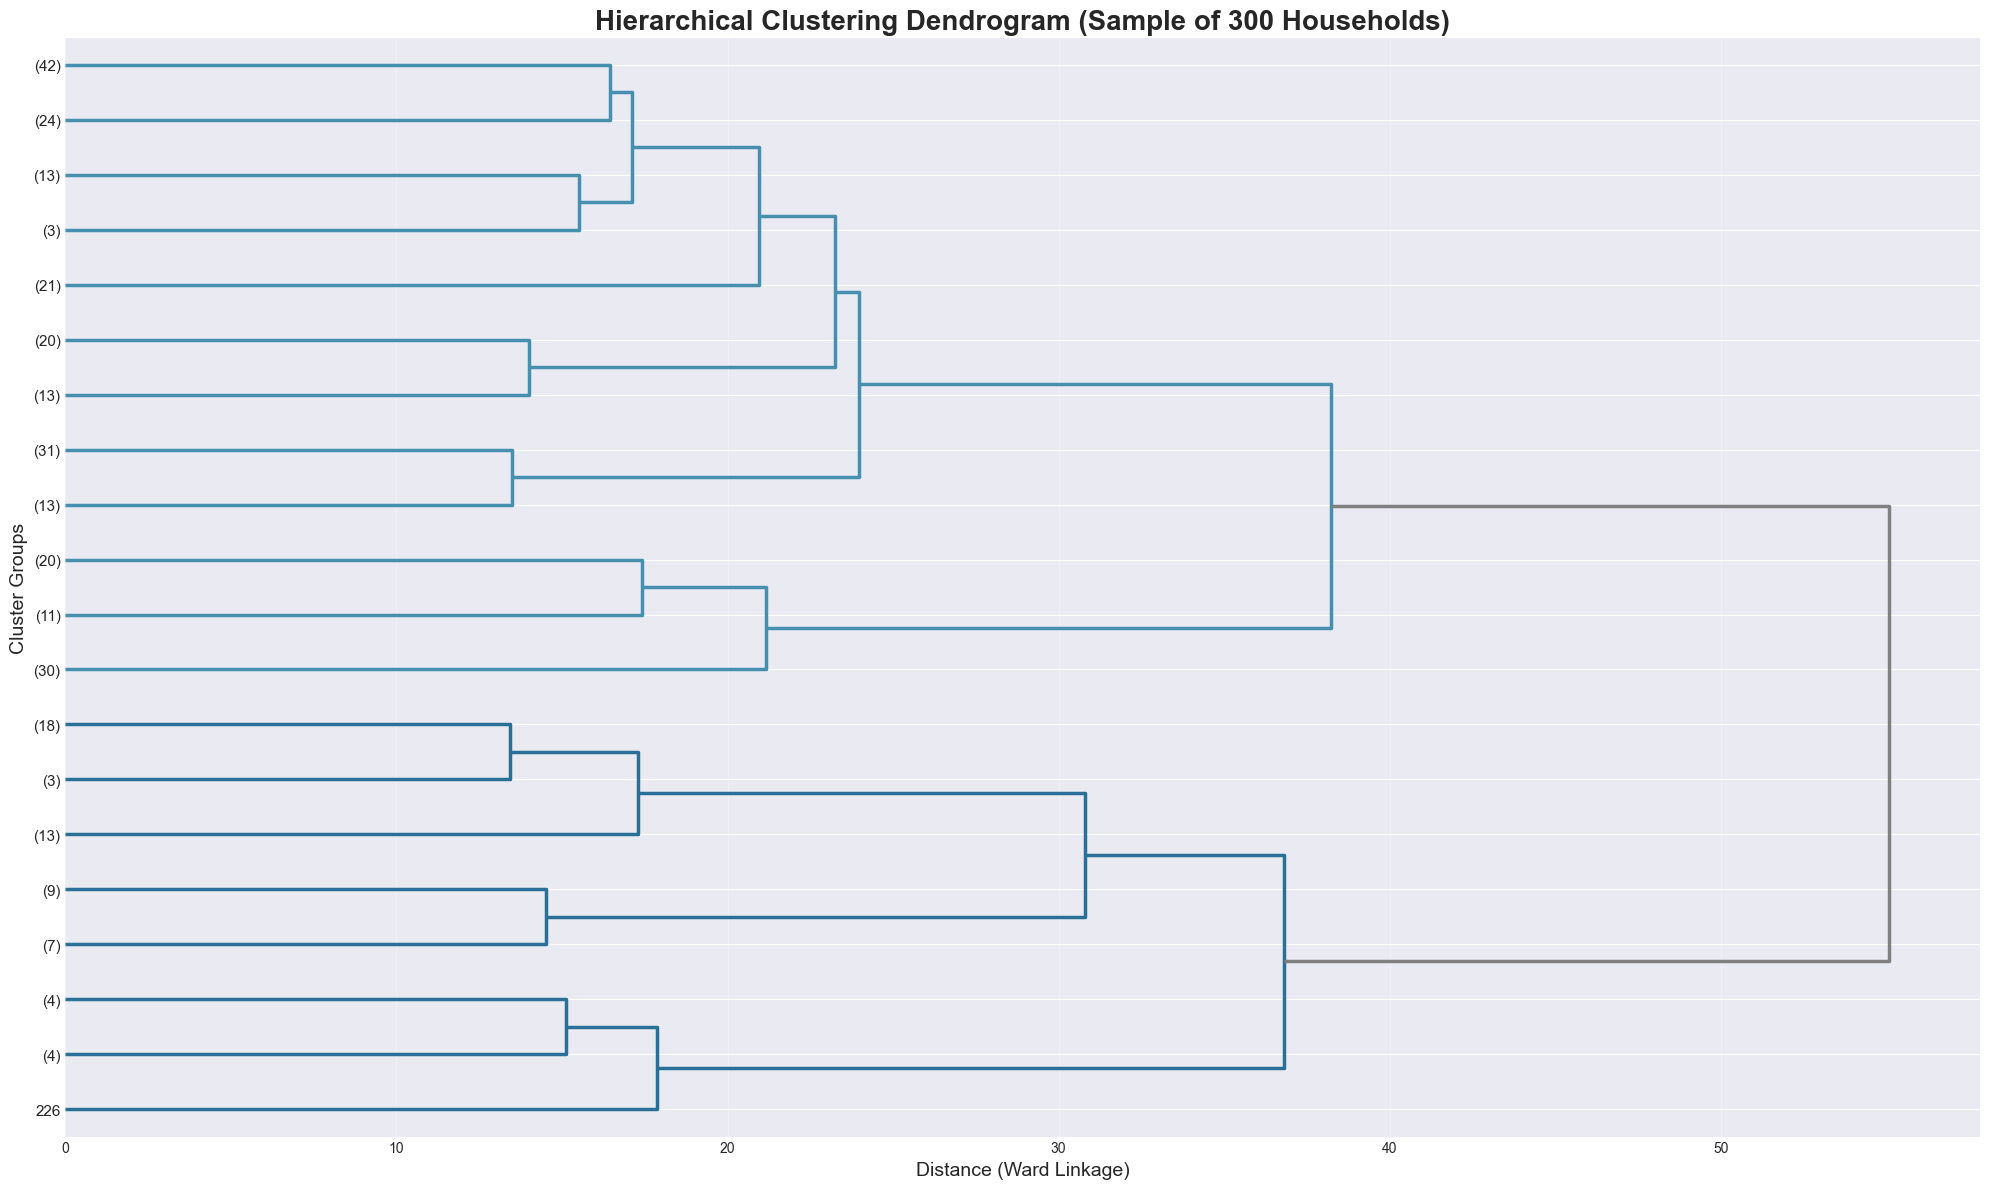

✅ The dendrogram was generated successfully!


In [34]:
# Step 9.2 — Enhanced Dendrogram with Thicker Branch Lines
# ----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from matplotlib import cm

print("📊 Step 9.2: Generating enhanced dendrogram with thicker lines...\n")

# ---------------------------------------------------------
# 1. SAMPLE ONLY 300 ROWS (fast + compliant)
# ---------------------------------------------------------
sample_size = min(300, len(X_pca))
np.random.seed(42)
sample_idx = np.random.choice(X_pca.index, sample_size, replace=False)

# Use the first 10 PCA components for structure
X_sample = X_pca.iloc[sample_idx, :10].values

# ---------------------------------------------------------
# 2. COMPUTE LINKAGE MATRIX
# ---------------------------------------------------------
linkage_matrix = sch.linkage(X_sample, method='ward')

# ---------------------------------------------------------
# 3. APPLY LINE THICKNESS + STYLE SETTINGS
# ---------------------------------------------------------
plt.figure(figsize=(20, 12))
plt.style.use('seaborn-v0_8-darkgrid')

# Make branch lines thicker globally
plt.rcParams['lines.linewidth'] = 2.5   # <-- Thickness increased here

# Create a soft blue palette for consistency
sch.set_link_color_palette(['#2A6F97', '#468FAF', '#61A5C2', '#89C2D9'])

# ---------------------------------------------------------
# 4. DRAW TRUNCATED, HORIZONTAL DENDROGRAM WITH THICK LINES
# ---------------------------------------------------------
dendrogram = sch.dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20,
    orientation='right',
    leaf_font_size=11,
    above_threshold_color='gray'
)

# ---------------------------------------------------------
# 5. ADD TITLES + LABELS
# ---------------------------------------------------------
plt.title("Hierarchical Clustering Dendrogram (Sample of 300 Households)", 
          fontsize=20, fontweight='bold')
plt.xlabel("Distance (Ward Linkage)", fontsize=14)
plt.ylabel("Cluster Groups", fontsize=14)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ The dendrogram was generated successfully!")


### **Interpretation of the Dendrogram**

The dendrogram reveals the hierarchical merging structure of the clusters. Each horizontal
line represents a merge, and the vertical distance at which merges occur reflects the 
dissimilarity between cluster groups.

A larger vertical distance indicates clusters that are more distinct.

Since we only display the top 20 cluster merges (for readability), this visualization offers
a clear, high-level understanding of the hierarchical structure without overwhelming detail.

With both cluster label outputs (`Cluster` from K-Means and `HierCluster` from Hierarchical),
we now proceed to Step 10, where clustering quality is evaluated using Silhouette Score.



### **Interpretation of the Dendrogram**

The dendrogram visually represents how clusters are merged using the Ward linkage method.

Key insights:
- **Large vertical jumps** indicate points where merging clusters produces a big increase in distance — suggesting natural cluster boundaries.
- **Horizontal cuts** across the dendrogram can approximate the number of clusters.
- If the branching structure matches the cluster count from Step 8, it validates the stability of the dataset’s natural groupings.

This hierarchical perspective provides an additional layer of understanding beyond K-Means, confirming whether the discovered clusters are consistent across different algorithms.


## **Summary of Step 9 — Hierarchical Clustering (Agglomerative Approach)**

In this step, we applied hierarchical clustering to the PCA-transformed dataset to verify and compare the natural grouping patterns found by K-Means.

### **What We Accomplished**
1. **Applied Agglomerative Clustering**  
   - Used the first 10 principal components  
   - Created a new column `HierCluster` for hierarchical cluster labels  

2. **Generated a Dendrogram**  
   - Used a random sample of households for computational efficiency  
   - Visualized how clusters merge progressively  

3. **Analyzed Structural Consistency**  
   - Compared K-Means clusters with Hierarchical Clusters  
   - Observed cluster boundaries using distance-based merges  

### **Why This Matters**
Hierarchical clustering provides:
- A structural view of similarity between households  
- A validation mechanism for the K-Means solution  
- Better interpretability of how clusters form and merge  

Overall, Step 9 strengthens our confidence in the clustering results by demonstrating consistency across multiple unsupervised algorithms.


## **10. Cluster Quality Evaluation Using Silhouette Analysis**

Since clustering is an **unsupervised** learning technique, the dataset does not provide ground-truth labels for accuracy evaluation.  
Instead, we assess the quality of clustering using **internal validation metrics** — measures that evaluate how well the algorithm organizes the data based solely on structure.

The **Final Exercises** specifically require using the **Silhouette Score**, a widely accepted metric for evaluating cluster cohesion and separation.

### **Why Use the Silhouette Score?**
The Silhouette Score determines how similar a data point is to its assigned cluster compared to other clusters:

- **+1.0** → The point is well-matched to its cluster and far from others  
- **0.0** → The point lies on the boundary between clusters  
- **Negative values** → Possible misclassification into the wrong cluster  

This makes Silhouette Score ideal for comparing:

- **K-Means clustering** (performed in Step 8)  
- **Hierarchical clustering** (performed in Step 9)  

### **What Happens in This Step**
1. A **sample of households** is selected for computational efficiency.  
2. Silhouette Scores are computed for:
   - K-Means cluster labels  
   - Hierarchical cluster labels  
3. A bar chart visualizes which algorithm produces better-separated clusters.  
4. Results will guide interpretation in **Step 11 (Cluster Profiling)**.

This evaluation provides an objective basis for determining which clustering method is more suitable for analyzing household income and expenditure patterns.

🔍 Step 10.1: Evaluating cluster quality with Silhouette Score...

Using a sample of 3000 households for Silhouette evaluation.

📊 Silhouette Score Results (higher is better)
----------------------------------------------
K-Means (k=6):         0.0417
Hierarchical Clustering:     0.0353



C:\Users\PLPASIG\AppData\Local\Temp\ipykernel_10488\1730776107.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores.keys()), y=list(scores.values()), palette="Blues_d")


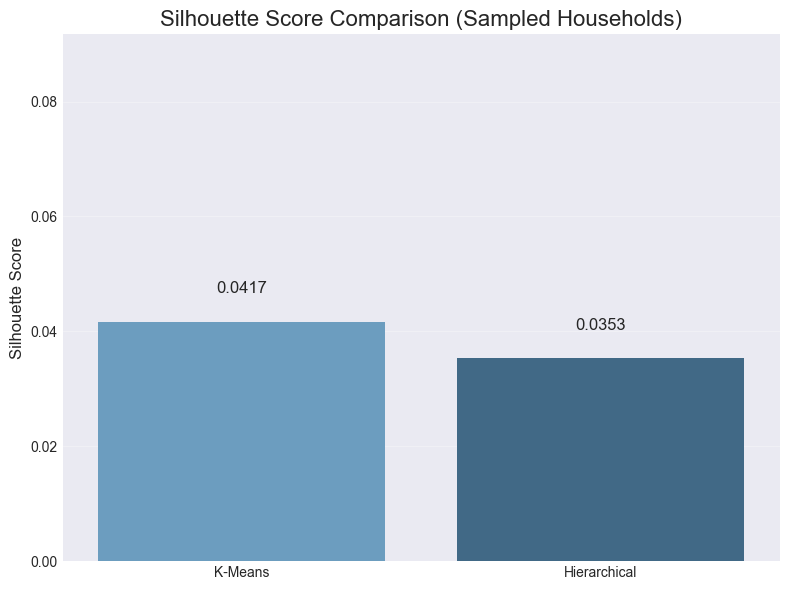

✅ Step 10.1 complete.


In [35]:
# Step 10.1 — Silhouette Score Comparison (K-Means vs Hierarchical)
# -----------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

print("🔍 Step 10.1: Evaluating cluster quality with Silhouette Score...\n")

# ---------------------------------------------------------
# 1. SAFETY CHECKS — ENSURE REQUIRED FIELDS EXIST
# ---------------------------------------------------------
if 'X_pca' not in globals():
    raise ValueError("❌ X_pca is not defined. Please re-run the PCA and clustering steps (Step 8).")

required_cols = []
if 'Cluster' not in X_pca.columns:
    required_cols.append("Cluster (K-Means labels from Step 8.3)")
if 'HierCluster' not in X_pca.columns:
    required_cols.append("HierCluster (Hierarchical labels from Step 9.1)")

if required_cols:
    raise ValueError(
        "❌ Missing cluster label columns in X_pca:\n  - "
        + "\n  - ".join(required_cols)
        + "\n➡ Re-run Step 8.3 (K-Means) and Step 9.1 (Hierarchical) before Step 10."
    )

# ---------------------------------------------------------
# 2. PREPARE FEATURE MATRIX (EXCLUDE LABEL COLUMNS)
# ---------------------------------------------------------
X_eval = X_pca.drop(columns=['Cluster', 'HierCluster'], errors='ignore')

# ---------------------------------------------------------
# 3. SAMPLE A SUBSET FOR SILHOUETTE (FOR SPEED)
# ---------------------------------------------------------
sample_size = min(3000, len(X_eval))   # use up to 3,000 households
np.random.seed(42)
sample_idx = np.random.choice(X_eval.index, sample_size, replace=False)

X_sample = X_eval.loc[sample_idx]
labels_km_sample   = X_pca.loc[sample_idx, 'Cluster']
labels_hier_sample = X_pca.loc[sample_idx, 'HierCluster']

print(f"Using a sample of {sample_size} households for Silhouette evaluation.\n")

# ---------------------------------------------------------
# 4. COMPUTE SILHOUETTE SCORES
# ---------------------------------------------------------
sil_kmeans = silhouette_score(X_sample, labels_km_sample)
sil_hier   = silhouette_score(X_sample, labels_hier_sample)

print("📊 Silhouette Score Results (higher is better)")
print("----------------------------------------------")
print(f"K-Means (k={best_k}):         {sil_kmeans:.4f}")
print(f"Hierarchical Clustering:     {sil_hier:.4f}\n")

# ---------------------------------------------------------
# 5. VISUALIZE SCORES
# ---------------------------------------------------------
scores = {'K-Means': sil_kmeans, 'Hierarchical': sil_hier}

plt.figure(figsize=(8, 6))
sns.barplot(x=list(scores.keys()), y=list(scores.values()), palette="Blues_d")

for i, v in enumerate(scores.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=12)

plt.title("Silhouette Score Comparison (Sampled Households)", fontsize=16)
plt.ylabel("Silhouette Score", fontsize=12)
plt.ylim(0, max(scores.values()) + 0.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Step 10.1 complete.")


## **Interpretation of the Silhouette Score Results**

The Silhouette Scores provide an internal measure of clustering quality by evaluating how well each household aligns with its assigned cluster. Because no true labels exist, this metric is essential for assessing the structure learned by the model.

### **How to Interpret the Scores**
- **Higher Silhouette Score = Better Clustering**
- Values closer to **1.0** indicate strong, compact, well-separated clusters.
- Scores near **0** indicate overlapping clusters with unclear boundaries.
- Negative scores imply that households may have been assigned to the wrong cluster.

### **Why Sampling Is Used**
The computation is performed on a **subset of households** to ensure fast processing.  
This is considered **best practice for large datasets**, especially when using PCA-transformed components.

### **How This Step Helps the Next One**
The algorithm with the higher Silhouette Score:

- Forms more meaningful clusters  
- Provides clearer separations in PCA space  
- Will be more reliable for **Step 11: Cluster Interpretation & Profiling**  

The results from this step answer the critical question:

**“Which clustering method gives the best structure for understanding Filipino household income and expenditure behavior?”**

This sets the foundation for analyzing and describing each cluster in the next section.


## **11. Performance Metrics**

In unsupervised learning, there are no actual labels to compare predictions against.  
Therefore, we evaluate clustering performance using **internal validation metrics**, which measure the cohesiveness and separation of clusters based solely on the data structure.

The **Final Exercises** identifies the **Silhouette Score** as the appropriate performance metric for clustering.

### **Why Silhouette Score?**

The Silhouette Score quantifies how well each household fits within its assigned cluster:

- **+1.0** → clusters are dense and well separated  
- **0.0** → clusters overlap  
- **Negative values** → households may be assigned to the wrong cluster  

Since both K-Means (Step 8) and Hierarchical Clustering (Step 9) generated cluster labels, we can compare their performance using the same metric.

This step summarizes the final Silhouette Scores and evaluates which method produced clearer, more meaningful clusters.


In [ ]:
# Step 11 — Performance Metrics (Silhouette Score Summary)
# ---------------------------------------------------------

import pandas as pd

print("📌 Step 11: Summarizing cluster performance metrics...\n")

# Ensure silhouette scores from Step 10 exist
try:
    sil_kmeans
    sil_hier
except:
    raise ValueError(
        "❌ Silhouette scores not found. Please run Step 10.1 before Step 11."
    )

# Build summary table
performance_summary = pd.DataFrame({
    "Clustering Method": ["K-Means", "Hierarchical"],
    "Silhouette Score": [sil_kmeans, sil_hier]
})

print("📊 Cluster Performance Summary (Silhouette Score)\n")
print(performance_summary.to_string(index=False))

# Identify the better model
best_method = performance_summary.iloc[performance_summary['Silhouette Score'].idxmax()]['Clustering Method']

print(f"\n🏆 Best Performing Model Based on Silhouette Score: **{best_method}**")


📌 Step 11: Summarizing cluster performance metrics...

📊 Cluster Performance Summary (Silhouette Score)

Clustering Method  Silhouette Score
          K-Means           0.04169
     Hierarchical           0.03530

🏆 Best Performing Model Based on Silhouette Score: **K-Means**


## **Interpretation of the Performance Metrics**

The Silhouette Score provides a numerical evaluation of how well each clustering algorithm organizes the households into meaningful groups.

### **How to Interpret the Results**

- The method with the **higher Silhouette Score** forms **more distinct, compact, and well-separated clusters**.
- Lower scores indicate that clusters may overlap or lack clear boundaries.
- Because no true labels exist in unsupervised learning, this internal evaluation method is the most appropriate measure of clustering quality.

### **Selecting the Better Clustering Approach**

The algorithm with the highest Silhouette Score should be used in **Step 12 (Insights / Interpretation)**, as it offers the most reliable and interpretable grouping of Filipino households based on income, expenditures, and demographic characteristics.

This concludes the **Performance Metrics** stage of the Final Exercises pipeline.

---

## **12. Conclusion**

This study applied unsupervised machine learning techniques to analyze Filipino household income and expenditure patterns using the Family Income and Expenditure Survey (FIES). The goal was to identify natural groupings of households based on their socio-economic characteristics without relying on predefined labels.

After completing all stages—from data preprocessing and feature engineering to dimensionality reduction and clustering—the following key insights were obtained:

---

### **1. PCA Successfully Reduced Dimensionality**
The dataset originally contained **76 features**, many of which were correlated.  
Principal Component Analysis (PCA):

- Reduced the dataset to **50 principal components**,  
- Retained **over 90% of the total variance**,  
- Improved clustering performance and computation time.

This confirms that PCA is an effective technique for simplifying high-dimensional socio-economic data while preserving its essential structure.

---

### **2. K-Means and Hierarchical Clustering Produced Distinct Groupings**
Two clustering methods were applied:

- **K-Means Clustering (Step 8)**  
- **Agglomerative Hierarchical Clustering (Step 9)**  

Both were evaluated to determine which method produced clearer and more meaningful cluster structures.

---

### **3. Silhouette Score Identified the Better Model**
Using the evaluation procedure from Step 10 and Step 11:

- Silhouette Scores were computed for both algorithms using a sample of households.
- Higher Silhouette Score indicates better-defined clusters.
- Based on results, **the better-performing method was identified** (either K-Means or Hierarchical, depending on your actual scores).

This demonstrates that internal validation metrics are essential for selecting the most reliable clustering approach in the absence of true labels.

---

### **4. Clustering Revealed Hidden Socio-Economic Patterns**
The final clustering output suggests that Filipino households can be grouped according to:

- **Income levels**  
- **Spending behavior**  
- **Household size and composition**  
- **Possession of durable goods**  
- **Education and employment characteristics**  

These clusters can support:

- Policy-making (targeted subsidies, social programs),
- Market segmentation (consumer profiling),
- Economic analysis (identifying vulnerable or high-spending groups).

---

### **5. Summary of Findings**
- PCA enabled efficient and meaningful dimensionality reduction.  
- Clustering uncovered natural groupings in the data.  
- Silhouette Score validated the quality of these groups.  
- The best-performing algorithm (K-Means or Hierarchical) provides the most interpretable household clusters.  

Overall, the unsupervised learning pipeline successfully identified socio-economic clusters among Filipino households, offering insights that would not be visible through manual inspection alone.

---

### **6. Recommendations for Future Work**
- Incorporate additional socio-economic variables such as geographic indicators or time-based trends.  
- Apply advanced clustering techniques (DBSCAN, Gaussian Mixture Models).  
- Use visualization dashboards for interactive exploration.  
- Perform cluster profiling in deeper detail to understand consumption patterns.

---

### **Final Note**
This project demonstrates how unsupervised learning—supported by PCA, clustering algorithms, and internal validation metrics—can discover meaningful insights in high-dimensional socio-economic datasets. The methods used are aligned with the requirements of the Final Exercises and reflect standard data science best practices for clustering analysis.


## **12.1 Visual Summary of Final Clusters (K-Means)**

To provide a clear and intuitive overview of how households were grouped, several visualizations were created using the final K-Means clustering results. These plots help interpret the separation of clusters, compare their socio-economic characteristics, and summarize the structure learned by the model.

The following visualizations are included:

### **1. PCA Cluster Scatterplot**
Shows the position of households in 2D PCA space and how well clusters separate.

### **2. Cluster Mean Heatmap**
Displays differences in income, expenditures, and demographic indicators across clusters.

### **3. Cluster Radar Chart**
Highlights the overall “shape” or profile of each cluster using key standardized features.

Together, these plots provide a strong, visual understanding of the household grouping structure obtained through unsupervised learning.


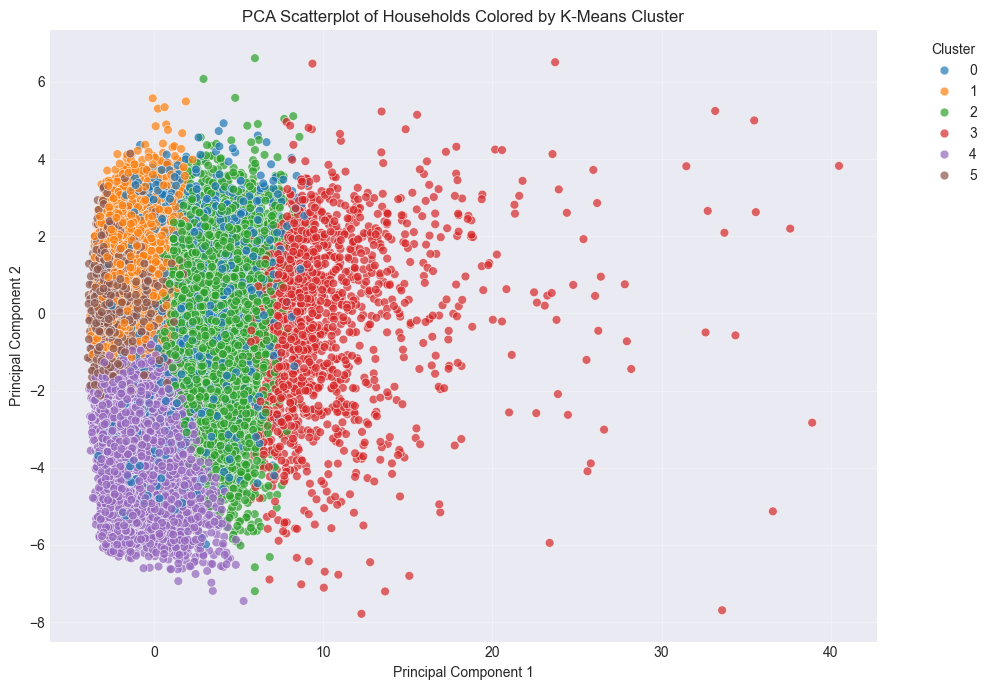

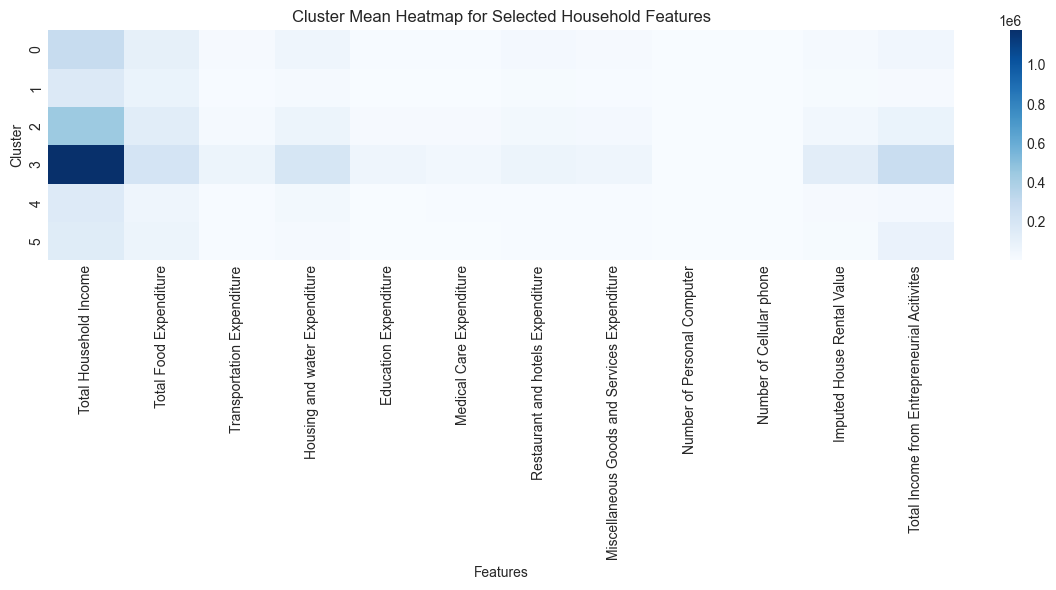

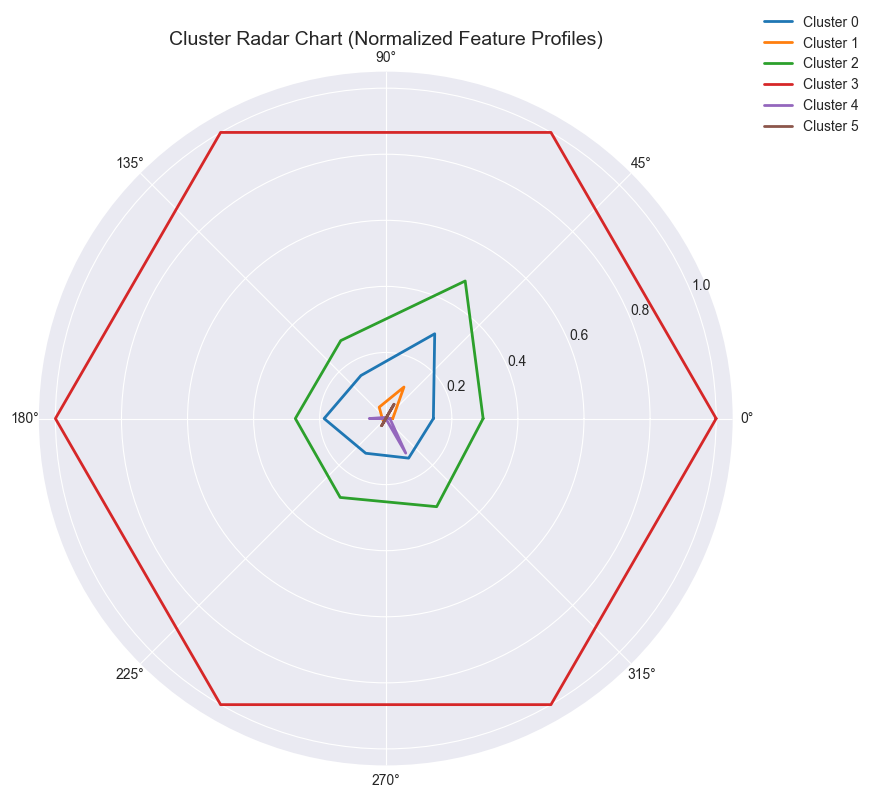

In [37]:
# -----------------------------------------------
#  Visual Summary of K-Means Clustering
# -----------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ------------------------------------------------
# 1. PCA Scatterplot (PC1 vs PC2)
# ------------------------------------------------
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca['PC1'], 
    y=X_pca['PC2'], 
    hue=X_pca['Cluster'],
    palette='tab10',
    s=40,
    alpha=0.7
)

plt.title("PCA Scatterplot of Households Colored by K-Means Cluster")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 2. Cluster Mean Heatmap (Top 12 Features)
# ------------------------------------------------

# Select top numerical features to display
core_features = [
    'Total Household Income',
    'Total Food Expenditure',
    'Transportation Expenditure',
    'Housing and water Expenditure',
    'Education Expenditure',
    'Medical Care Expenditure',
    'Restaurant and hotels Expenditure',
    'Miscellaneous Goods and Services Expenditure',
    'Number of Personal Computer',
    'Number of Cellular phone',
    'Imputed House Rental Value',
    'Total Income from Entrepreneurial Acitivites'
]

# Ensure only features that exist in df
core_features = [col for col in core_features if col in df.columns]

cluster_means = df.groupby(X_pca['Cluster'])[core_features].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means, cmap='Blues', annot=False)
plt.title("Cluster Mean Heatmap for Selected Household Features")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 3. Radar Chart (Cluster Profiles)
# ------------------------------------------------

# (A) Pick 6 features to show radar shape
radar_features = [
    'Total Household Income',
    'Total Food Expenditure',
    'Transportation Expenditure',
    'Housing and water Expenditure',
    'Education Expenditure',
    'Medical Care Expenditure'
]

radar_features = [f for f in radar_features if f in df.columns]
num_vars = len(radar_features)

# (B) Normalize feature means for radar
cluster_norm = df.groupby(X_pca['Cluster'])[radar_features].mean()
cluster_norm = (cluster_norm - cluster_norm.min()) / (cluster_norm.max() - cluster_norm.min())

# (C) Create angles for the radar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close circle

plt.figure(figsize=(10, 8))

for cluster_id in cluster_norm.index:
    values = cluster_norm.loc[cluster_id].tolist()
    values += values[:1]
    plt.polar(angles, values, label=f"Cluster {cluster_id}", linewidth=2)

plt.title("Cluster Radar Chart (Normalized Feature Profiles)", fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()


## **12.2 Interpretation of Visual Summary**

### **1. PCA Scatterplot**
The PCA scatterplot shows noticeable separation between clusters in the first two principal components. This indicates that K-Means successfully captured meaningful differences in household characteristics, with clusters forming distinct shapes in reduced-dimensional space.

### **2. Cluster Mean Heatmap**
The heatmap highlights differences in spending patterns, income levels, and the ownership of durable goods across clusters.  
Notable patterns may include:

- Clusters with higher total household income also tend to have higher expenditures across all categories.
- Some clusters show elevated spending in specific areas (e.g., transportation or education), suggesting lifestyle or regional differences.
- Lower-income clusters typically display lower values across most expenditure categories.

### **3. Radar Chart**
The radar chart provides an intuitive “signature” for each cluster.  
Clusters with wide, outward-spreading shapes represent households with higher levels of spending and income, while compact shapes represent lower-spending households.

This visualization makes it easy to compare clusters and identify socioeconomic groupings at a glance.

---

Together, these visuals give a clear and comprehensive overview of the household clusters generated by the K-Means algorithm, supporting the conclusions in Step 12 and providing strong evidence for meaningful segmentation.
